## Upholstered Bed 시장 분석

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [3]:
import re
from sklearn.feature_extraction.text import CountVectorizer
#from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import MultipleLocator, FuncFormatter
from wordcloud import WordCloud, STOPWORDS

In [4]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [9]:
sql = f"""
select * from wook.stckln_amz_non_mattress_ms_trend 
where gpt_sub_category = 'Upholstered PB'
"""

df_uphols = bqclient.query(sql).to_dataframe()

In [11]:
print(df_uphols)

       RetailerSku gpt_financial_category gpt_sub_category gpt_style_type  \
0       B0CGZWDML8       20.PLATFORM BEDS   Upholstered PB        Storage   
1       B0BGJB99W1       20.PLATFORM BEDS   Upholstered PB       Wingback   
2       B0BGJB99W1       20.PLATFORM BEDS   Upholstered PB       Wingback   
3       B0BGJB99W1       20.PLATFORM BEDS   Upholstered PB       Wingback   
4       B0BGJB99W1       20.PLATFORM BEDS   Upholstered PB       Wingback   
...            ...                    ...              ...            ...   
617631  B0F28Y24DH       20.PLATFORM BEDS   Upholstered PB           None   
617632  B0CP29GGRQ       20.PLATFORM BEDS   Upholstered PB        Storage   
617633  B0DGTMYT2Y       20.PLATFORM BEDS   Upholstered PB       Wingback   
617634  B0DGGGVZKT       20.PLATFORM BEDS   Upholstered PB        Storage   
617635  B0DLWNHYL5       20.PLATFORM BEDS   Upholstered PB       Wingback   

                                       rf_categories_flat rf_category  \
0 

In [15]:
df_uphols['RetailerSku'].nunique()

34778

## 1. SKU, Brand 집중도 

In [22]:
df1 = df_uphols.copy()

In [24]:
df1['year'] = df1['yr_month'].str[:2].astype(int) + 2000
df_2025 = df1[df1['year'] == 2025].copy()

In [26]:
df_2025['RetailerSku'].nunique()

16596

#### - ASIN별 집중도

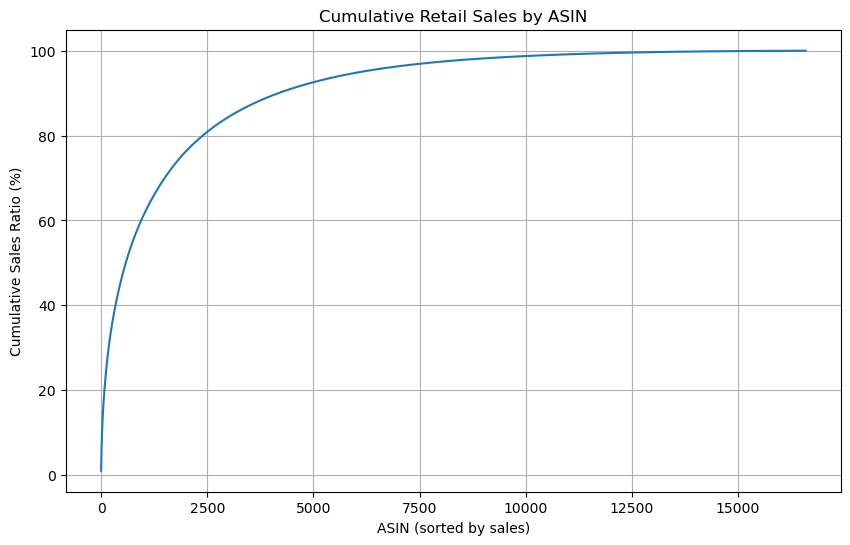

In [29]:
# 1. asin별 매출 합계
asin_sales = (
    df_2025.groupby("RetailerSku")["RetailSales"]
       .sum()
       .reset_index()
)

# 2. 매출 큰 순으로 정렬
asin_sales = asin_sales.sort_values("RetailSales", ascending=False).reset_index(drop=True)

# 3. 누적 매출 비율 계산
asin_sales["cum_sales"] = asin_sales["RetailSales"].cumsum()
asin_sales["cum_ratio"] = asin_sales["cum_sales"] / asin_sales["RetailSales"].sum() * 100

# 4. 누적 그래프 그리기
plt.figure(figsize=(10,6))
plt.plot(range(len(asin_sales)), asin_sales["cum_ratio"])
plt.xlabel("ASIN (sorted by sales)")
plt.ylabel("Cumulative Sales Ratio (%)")
plt.title("Cumulative Retail Sales by ASIN")
plt.grid(True)
plt.show()

In [31]:
asin_sales.to_csv('uphols_asin_sales_2025_1010.csv')

#### - Brand 집중도

In [34]:
df_2025['brand'].nunique()

601

In [36]:
# Brand_raw별 매출 합계 집계
brand_sales_2025 = (
    df_2025.groupby('brand')['RetailSales']
           .sum()
           .reset_index()
           .sort_values(by='RetailSales', ascending=False)
)

# 전체 매출 합계
total_sales = brand_sales_2025['RetailSales'].sum()

# 비율(Ratio) 계산
brand_sales_2025['Ratio'] = brand_sales_2025['RetailSales'] / total_sales

# 누적 비율(Cumul) 계산
brand_sales_2025['Cumul'] = brand_sales_2025['Ratio'].cumsum()
print(brand_sales_2025)

brand_sales_2025.to_csv('uphols_brand_2025_1010.csv', index=False)

                  brand  RetailSales         Ratio     Cumul
31              Allewie  68218246.75  1.599612e-01  0.159961
166             Feonase  19924423.46  4.671967e-02  0.206681
433           Rolanstar  16833714.35  3.947244e-02  0.246153
441          SHA CERLIN  16801895.22  3.939783e-02  0.285551
494              VECELO  15141121.36  3.550358e-02  0.321055
..                  ...          ...           ...       ...
325              Lohoms        99.99  2.344610e-07  0.999999
212               HNEBC        99.99  2.344610e-07  0.999999
92   Casa Andrea Milano        89.52  2.099105e-07  1.000000
151               Ewbob        79.99  1.875641e-07  1.000000
411         Progressive        78.75  1.846565e-07  1.000000

[601 rows x 4 columns]


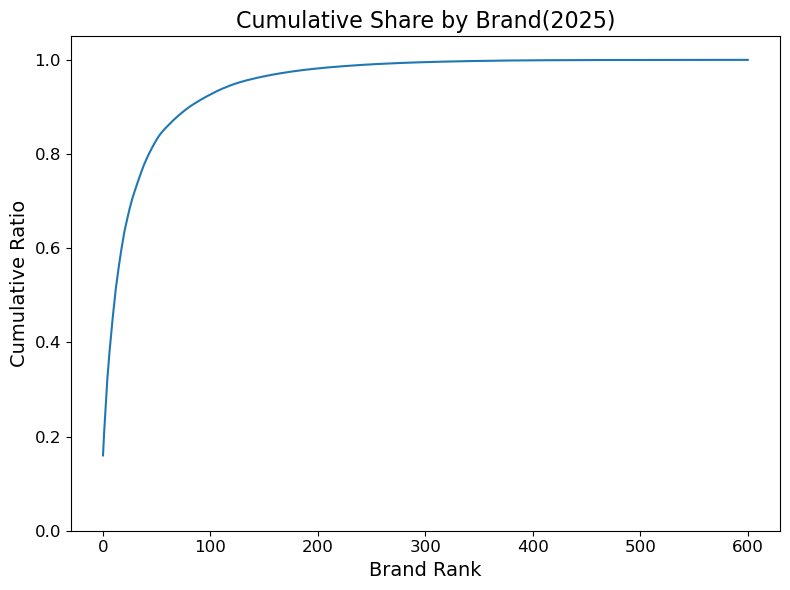

In [38]:
# x축 숫자 라벨 생성 (1부터 시작)
x_labels = list(range(0, len(brand_sales_2025)))

# 누적 점유율 그래프
plt.figure(figsize=(8, 6))
plt.plot(x_labels, brand_sales_2025['Cumul'])

# 제목과 축 라벨 폰트 크기 확대
plt.title("Cumulative Share by Brand(2025)", fontsize=16)
plt.xlabel("Brand Rank", fontsize=14)
plt.ylabel("Cumulative Ratio", fontsize=14)

plt.ylim(0, 1.05)

# x축 라벨을 100 단위로 설정 + 폰트 크기 조정
step = 100
plt.xticks(ticks=x_labels[::step], labels=x_labels[::step], fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

In [40]:
asin_sales.to_csv('adjustable_2025_asin_sales_0902.csv')

In [30]:
df1.groupby('year')['RetailSales'].sum()

year
2021    2.058923e+08
2022    3.225624e+08
2023    4.466057e+08
2024    5.883555e+08
2025    4.459256e+08
Name: RetailSales, dtype: float64

## 2. 가격대별 매출

In [13]:
df1 = df_uphols.copy()
df1['year'] = df1['yr_month'].str[:2].astype(int) + 2000
df_2025 = df1[df1['year'] == 2025].copy()

In [15]:
print(df_2025)

       RetailerSku gpt_financial_category gpt_sub_category gpt_style_type  \
430286  B0D9GN167Q       20.PLATFORM BEDS   Upholstered PB        Storage   
430287  B0C81DXXS5       20.PLATFORM BEDS   Upholstered PB        Storage   
430288  B0DPX2P1PT       20.PLATFORM BEDS   Upholstered PB        Storage   
430289  B0B1Q1MDHJ       20.PLATFORM BEDS   Upholstered PB        Storage   
430290  B0CHS8WR14       20.PLATFORM BEDS   Upholstered PB        Storage   
...            ...                    ...              ...            ...   
617631  B0DS4GQ4Q5       20.PLATFORM BEDS   Upholstered PB        Storage   
617632  B0DCFN1HCC       20.PLATFORM BEDS   Upholstered PB       Wingback   
617633  B0FHPPGQK7       20.PLATFORM BEDS   Upholstered PB           None   
617634  B0CB8PKMFW       20.PLATFORM BEDS   Upholstered PB       Wingback   
617635  B0DM62WCKX       20.PLATFORM BEDS   Upholstered PB        Storage   

                                       rf_categories_flat rf_category  \
43

In [17]:
df_2025['RetailPrice'].isna().sum()

0

#### - 고정 가격대 (GOC 버전)

In [27]:
df2 = df_2025.copy()

# 2) Price Bin 정의
price_bins = [1, 50, 100, 150, 200, 250, 300, 400, 600, 1000, np.inf]
bin_labels = [ "1~49.99", "50~99.99", 
              "100~149.99", "150~199.99", "200~249.99", "250~299.99",
              "300~399.99", "400~599.99", "600~999.99", "1000+"]

# 3) 가격 버킷 할당
df2['PriceBin'] = pd.cut(
    df2['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,
    include_lowest=True
)

# 4) Price Bin별 매출합 + 비율
sales_by_bin = (
    df2.groupby('PriceBin', observed=True)['RetailSales']
    .sum()
    .reindex(bin_labels)
    .fillna(0)
)
#print(sales_by_bin)

total_sales = sales_by_bin.sum()
share = (sales_by_bin / total_sales).fillna(0)
#print(share)

# 5) Million 단위로 변환
result = (
    pd.DataFrame({
        'RetailSales(M)': (sales_by_bin / 1_000_000).round(2),  # 백만 단위
        'Share(%)': (share * 100).round(2)
    })
    .reset_index()
    .rename(columns={'index': 'PriceBin'})
)

result['PriceBin'] = pd.Categorical(result['PriceBin'], categories=bin_labels, ordered=True)
result = result.sort_values('PriceBin').reset_index(drop=True)

print(result)

     PriceBin  RetailSales(M)  Share(%)
0     1~49.99            0.50      0.11
1    50~99.99           20.97      4.70
2  100~149.99          115.77     25.96
3  150~199.99          124.35     27.88
4  200~249.99           66.65     14.95
5  250~299.99           46.70     10.47
6  300~399.99           45.59     10.22
7  400~599.99           18.70      4.19
8  600~999.99            3.28      0.73
9       1000+            3.43      0.77


In [25]:
result['RetailSales(M)'].sum()

445.92999999999995

#### - Percentile 가격대

In [23]:
df3 = df_2025.copy()

# --- 2) 가격의 10분위(Deciles) 경계 계산 (표시용) ---
# 0%,10%,...,100% 경계
q_edges = df3['RetailPrice'].quantile(np.linspace(0, 1, 11)).to_numpy()

def fmt_range(lo, hi, i, n=2):
    # 마지막 구간은 닫힌 구간으로 표현
    if i < 9:
        return f"[{round(lo, n):,.2f} ~ {round(hi, n):,.2f})"
    else:
        return f"[{round(lo, n):,.2f} ~ {round(hi, n):,.2f}]"

price_ranges = [fmt_range(q_edges[i], q_edges[i+1], i) for i in range(10)]
labels = [f"D{i:02d}" for i in range(1, 11)]

# --- 3) 분위 기반 10등분 (동일값이 많아 경계가 겹치면 rank로 보정) ---
try:
    decile_cat = pd.qcut(
        df3['RetailPrice'],
        q=10,
        labels=labels,
        duplicates='drop'  # 중복 경계는 자동 축소
    )
    # 만약 10개 미만으로 축소되면 rank 기반으로 강제 10등분
    if len(decile_cat.cat.categories) < 10:
        raise ValueError("Not enough unique edges for 10 bins.")
except Exception:
    # 동일가가 많아 qcut이 실패/축소될 때: 순위로 강제 10등분
    tmp_rank = df3['RetailPrice'].rank(method='first')
    decile_cat = pd.qcut(tmp_rank, q=10, labels=labels)

df3['Decile'] = decile_cat

# --- 4) 각 Decile 매출 합계 및 비중 ---
sales_by_decile = (
    df3.groupby('Decile', observed=True)['RetailSales']
               .sum()
               .reindex(labels)
               .fillna(0)
)

total_sales = sales_by_decile.sum()
share_pct = (sales_by_decile / total_sales * 100).fillna(0)

# (선택) 건수도 같이 보고 싶다면:
count_by_decile = (
    df3.groupby('Decile', observed=True)['RetailPrice']
               .count()
               .reindex(labels)
               .fillna(0)
               .astype(int)
)

# --- 5) 결과 테이블 ---
# 가격 구간 문자열 매핑 (bins가 축소되었을 때도 10개를 유지하기 위해 q_edges 기반)
range_map = {lab: price_ranges[i] for i, lab in enumerate(labels)}

result_deciles = (
    pd.DataFrame({
        'Decile': labels,
        'PriceRange': [range_map[l] for l in labels],
        'RetailSales(M)': (sales_by_decile / 1_000_000).round(2),
        'Share(%)': share_pct.round(2),
        'Count': count_by_decile
    })
)

print(result_deciles)

       Decile           PriceRange  RetailSales(M)  Share(%)  Count
Decile                                                             
D01       D01     [12.49 ~ 109.99)           37.02      8.30  21134
D02       D02    [109.99 ~ 129.99)           42.77      9.59  19115
D03       D03    [129.99 ~ 147.99)           43.42      9.74  15975
D04       D04    [147.99 ~ 159.99)           44.23      9.92  18729
D05       D05    [159.99 ~ 179.99)           46.36     10.40  20566
D06       D06    [179.99 ~ 199.99)           47.80     10.72  19151
D07       D07    [199.99 ~ 229.99)           44.91     10.07  17318
D08       D08    [229.99 ~ 269.99)           41.03      9.20  18328
D09       D09    [269.99 ~ 339.99)           48.04     10.77  18608
D10       D10  [339.99 ~ 4,049.00]           50.35     11.29  18426


In [85]:
result_deciles['RetailSales(M)'].sum()

426.48

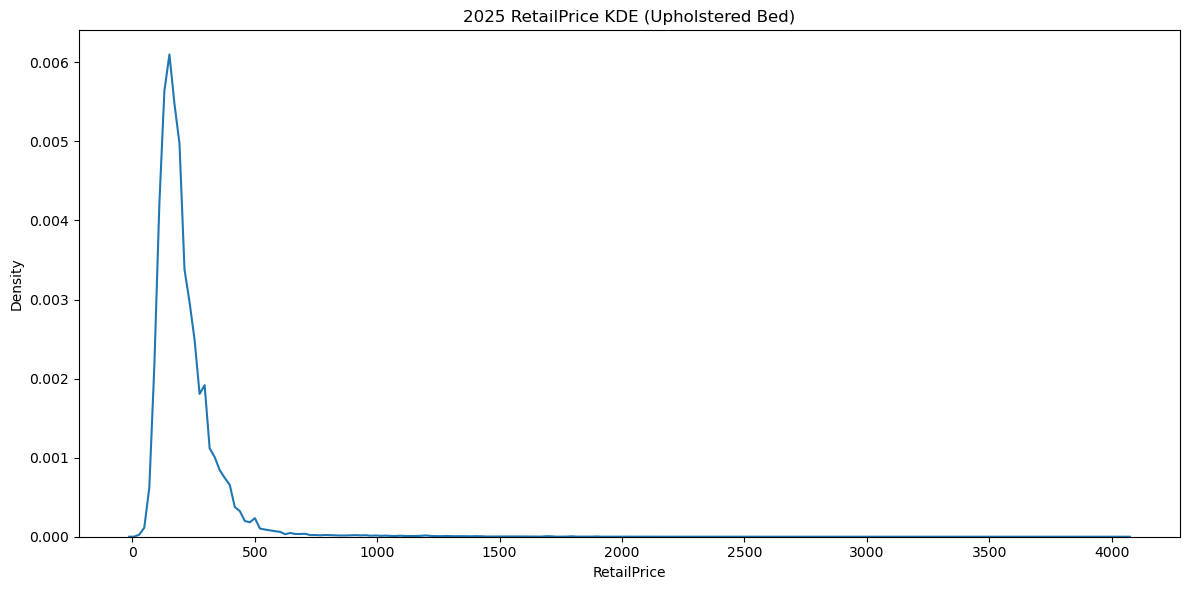

In [79]:
plt.figure(figsize=(12, 6))

# KDE 플롯 (log 변환 없이)
prices = df_2025['RetailPrice'].dropna()
prices = prices[prices > 0]
sns.kdeplot(prices, bw_adjust=0.7)

plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 RetailPrice KDE (Upholstered Bed)')
plt.tight_layout()
plt.show()

## 3. Top Brand 매출

#### - 전체 기간 기준

In [13]:
df1 = df_uphols.copy()
df1['year'] = df1['yr_month'].str[:2].astype(int) + 2000

In [15]:
print(df1)

       RetailerSku gpt_financial_category gpt_sub_category gpt_style_type  \
0       B0CGZWDML8       20.PLATFORM BEDS   Upholstered PB        Storage   
1       B0BGJB99W1       20.PLATFORM BEDS   Upholstered PB       Wingback   
2       B0BGJB99W1       20.PLATFORM BEDS   Upholstered PB       Wingback   
3       B0BGJB99W1       20.PLATFORM BEDS   Upholstered PB       Wingback   
4       B0BGJB99W1       20.PLATFORM BEDS   Upholstered PB       Wingback   
...            ...                    ...              ...            ...   
617631  B0F28Y24DH       20.PLATFORM BEDS   Upholstered PB           None   
617632  B0CP29GGRQ       20.PLATFORM BEDS   Upholstered PB        Storage   
617633  B0DGTMYT2Y       20.PLATFORM BEDS   Upholstered PB       Wingback   
617634  B0DGGGVZKT       20.PLATFORM BEDS   Upholstered PB        Storage   
617635  B0DLWNHYL5       20.PLATFORM BEDS   Upholstered PB       Wingback   

                                       rf_categories_flat rf_category  \
0 

In [117]:
df1.fillna({'RetailSales': 0})
df1['RetailSales'].isna().sum()

0

In [17]:
# brand별 매출 합계 집계
brand_sales = (
    df1.groupby('brand')['RetailSales']
      .sum()
      .reset_index()
      .sort_values('RetailSales', ascending=False)
)

print(brand_sales.head(20))  # 매출 상위 20개 브랜드 출력

                  brand   RetailSales
47              Allewie  2.943373e+08
872               Zinus  1.716093e+08
698          SHA CERLIN  9.531914e+07
260             Feonase  6.420860e+07
687           Rolanstar  5.775675e+07
15             AMERLIFE  5.412374e+07
418           Jocisland  4.888988e+07
851           Yaheetech  4.424328e+07
458             LIKIMIO  4.397522e+07
176                 DHP  4.232185e+07
792              VECELO  3.965740e+07
921             iPormis  3.647052e+07
438              Keyluv  3.613357e+07
544  Meridian Furniture  3.333329e+07
565             Molblly  3.168177e+07
623             PaPaJet  2.360967e+07
325              HITHOS  2.241986e+07
339             HOSTACK  2.054358e+07
323               HIFIT  1.932995e+07
364           Home Life  1.889601e+07


In [19]:
# 2. 연도-브랜드별 매출 집계
brand_year_sales = (
    df1.groupby(['year','brand'])['RetailSales']
       .sum()
       .reset_index()
)

# 3. 전체 매출 기준 Top 10 브랜드 추출
top10_brands = (
    brand_year_sales.groupby('brand')['RetailSales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# 4. Others 포함
brand_year_sales['brand_top'] = brand_year_sales['brand'].where(
    brand_year_sales['brand'].isin(top10_brands), 'Others')

# 5. 연도별 매출 (Top10 + Others)
brand_year_sales_top10 = (
    brand_year_sales.groupby(['year','brand_top'])['RetailSales']
    .sum()
    .reset_index()
)

# 6. 피벗 (년도 x 브랜드 매출)
pivot_top10 = brand_year_sales_top10.pivot(index='year', columns='brand_top', values='RetailSales').fillna(0)
print(pivot_top10)


brand_top     AMERLIFE       Allewie          DHP      Feonase    Jocisland  \
year                                                                          
2021              0.00  2.630738e+07  19716893.15         0.00         0.00   
2022        2590809.19  3.495076e+07  13466273.61    510362.93    619205.05   
2023       19316676.57  5.748496e+07   6738144.69  14167855.89  14305823.53   
2024       21114216.91  1.038181e+08   1886214.03  29085408.99  21090650.35   
2025       11102036.02  7.177613e+07    514321.51  20444970.37  12874199.96   

brand_top      LIKIMIO        Others    Rolanstar   SHA CERLIN    Yaheetech  \
year                                                                          
2021              0.00  9.342108e+07         0.00         0.00    447332.36   
2022        3609378.09  1.759855e+08   4223406.16  25236807.38   4791272.45   
2023       11401721.25  2.456711e+08  11780840.16  22614599.72  12565939.06   
2024       18275099.19  3.142188e+08  24260176.27  

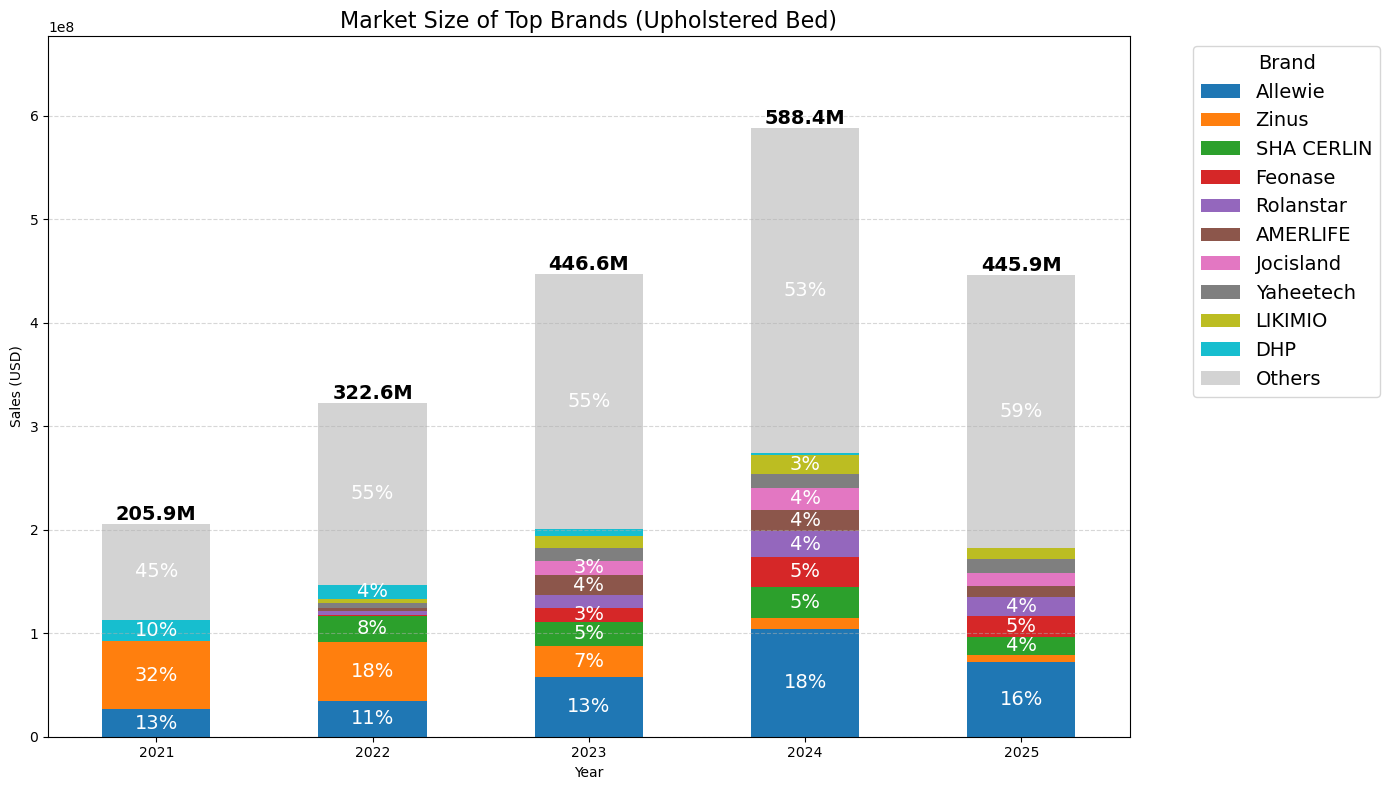

In [28]:
# 6-1. 브랜드별 총매출 합계 기준 내림차순
brand_totals = pivot_top10.sum(axis=0).sort_values(ascending=False)

# 6-2. Others를 맨 위로
if "Others" in brand_totals.index:
    brand_order = brand_totals.drop("Others").index.tolist() + ["Others"]
else:
    brand_order = brand_totals.index.tolist()

pivot_top10 = pivot_top10[brand_order]

# 7. 색상 지정 (Others = 회색)
colors = plt.cm.tab10.colors  # 기본 colormap에서 10개 색상
brand_colors = {b: colors[i % len(colors)] for i, b in enumerate(brand_order)}
if "Others" in brand_colors:
    brand_colors["Others"] = "lightgrey"

# 8. 누적 막대그래프
ax = pivot_top10.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    color=[brand_colors[b] for b in pivot_top10.columns]
)

plt.title("Market Size of Top Brands (Upholstered Bed)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Sales (USD)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# ✅ 범례 표시 (Others 포함)
plt.legend(title="Brand", bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=14, title_fontsize=14)

# ---------- 여기부터 추가: 비중(%) + 상단 총매출(M) 표기 ----------
# 연도(행)별 총매출
totals_per_year = pivot_top10.sum(axis=1)

# 상단 라벨이 잘 보이도록 여유공간 확보
ax.set_ylim(0, totals_per_year.max() * 1.15)

for i, idx in enumerate(pivot_top10.index):
    row = pivot_top10.loc[idx]
    total = totals_per_year.loc[idx]

    # 총매출이 0이면 스킵
    if total == 0:
        continue

    cum = 0.0
    for b in pivot_top10.columns:
        val = float(row[b]) if pd.notna(row[b]) else 0.0
        if val <= 0:
            continue

        share = val / total  # 비중 (0~1)
        y_center = cum + val / 2.0

        # 구간이 충분히 클 때는 구간 중앙에 흰색으로 %, 작으면 구간 위에 검정으로 표시
        if share >= 0.03:  # 6% 이상이면 내부에 표시
            ax.text(
                i, y_center, f"{share:.0%}",
                ha="center", va="center",
                fontsize=14, color="white"
            )
            
        cum += val

    # 막대 상단에 연도 총매출(Million) 라벨
    ax.text(
        i, total, f"{total/1_000_000:.1f}M",
        ha="center", va="bottom",
        fontsize=14, fontweight="bold"
    )
# ---------- 추가 끝 ----------

plt.tight_layout()
plt.show()

#### - 2025년 기준

In [181]:
df1 = df_uphols.copy()
df1['year'] = df1['yr_month'].str[:2].astype(int) + 2000
df1.fillna({'RetailSales': 0})

,RetailerSku,gpt_financial_category,gpt_sub_category,gpt_style_type,rf_categories_flat,rf_category,stck_category,bw_ff_type,brand,Title,...,RetailSales,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month,year
0,B08L6D1M7P,20.PLATFORM BEDS,Upholstered PB,None,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,05. Bed Frames,None,VECELO,14 Inch Premium Upholstered Platform Bed Frame...,...,122.43,1,122.43,21-4,21-11,Y21 W45,Y21 W45,29131231.80,687484.66,2021
1,B08L6D1M7P,20.PLATFORM BEDS,Upholstered PB,None,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,05. Bed Frames,None,VECELO,14 Inch Premium Upholstered Platform Bed Frame...,...,367.29,3,122.43,21-2,21-05,Y21 W19,Y21 W19,29131231.80,687484.66,2021
2,B00ASQ4Z3O,20.PLATFORM BEDS,Upholstered PB,None,Home & Kitchen > Furniture > Bedroom Furniture...,Beds,06. Beds,None,247SHOPATHOME,24/7 Shop at Home Kaylin Traditional Tufted He...,...,2060.00,1,2060.00,23-2,23-06,Y23 W23,Y23 W23,258875.84,2131.66,2023
3,B0CGZWDML8,20.PLATFORM BEDS,Upholstered PB,Storage,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,06. Beds,3p,Merax,"3-Pieces Bedroom Sets, Harper & Bright Designs...",...,0.00,0,0.00,24-1,24-01,Y24 W02,Y24 W02,71865984.24,12781118.83,2024
4,B0BPPLZVRH,20.PLATFORM BEDS,Upholstered PB,Storage,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,06. Beds,None,4 EVER WINNER,4 EVER WINNER Bed Frame Full Size Upholstered ...,...,1539.89,11,139.99,22-4,22-12,Y22 W52,Y22 W52,2466381.58,13247.14,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
626619,B0F1TMJ7D7,20.PLATFORM BEDS,Upholstered PB,Storage,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,06. Beds,3p,iPormis,iPormis King Size Bed Frame with 4 Storage Dra...,...,620.97,3,206.99,25-3,25-09,Y25 W37,Y25 W37,45664711.80,8171285.14,2025
626620,B0C7LG23JZ,20.PLATFORM BEDS,Upholstered PB,Storage,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,06. Beds,3p,iPormis,iPormis King Size Bed Frame with 4 Storage Dra...,...,689.97,3,229.99,25-3,25-09,Y25 W37,Y25 W37,45664711.80,8171285.14,2025
626621,B0DGGT98PJ,20.PLATFORM BEDS,Upholstered PB,Wingback,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,06. Beds,3p,iPormis,"iPormis Twin Bed Frame with 3 Storage Drawers,...",...,1299.87,13,99.99,25-3,25-09,Y25 W37,Y25 W37,45664711.80,8171285.14,2025
626622,B0CKRWRH26,20.PLATFORM BEDS,Upholstered PB,None,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,06. Beds,3p,iPormis,iPormis Twin Size Metal Bed Frame with Linen U...,...,119.96,2,59.98,25-3,25-09,Y25 W37,Y25 W37,45664711.80,8171285.14,2025


In [166]:
print(df1)

       RetailerSku gpt_financial_category gpt_sub_category gpt_style_type  \
0       B08L6D1M7P       20.PLATFORM BEDS   Upholstered PB           None   
1       B08L6D1M7P       20.PLATFORM BEDS   Upholstered PB           None   
2       B00ASQ4Z3O       20.PLATFORM BEDS   Upholstered PB           None   
3       B0CGZWDML8       20.PLATFORM BEDS   Upholstered PB        Storage   
4       B0BPPLZVRH       20.PLATFORM BEDS   Upholstered PB        Storage   
...            ...                    ...              ...            ...   
626619  B0F1TMJ7D7       20.PLATFORM BEDS   Upholstered PB        Storage   
626620  B0C7LG23JZ       20.PLATFORM BEDS   Upholstered PB        Storage   
626621  B0DGGT98PJ       20.PLATFORM BEDS   Upholstered PB       Wingback   
626622  B0CKRWRH26       20.PLATFORM BEDS   Upholstered PB           None   
626623  B0FHVVND55       20.PLATFORM BEDS   Upholstered PB       Wingback   

                                       rf_categories_flat rf_category  \
0 

In [176]:
# 2. 연도-브랜드별 매출 집계
brand_year_sales = (
    df1.groupby(['year','brand'])['RetailSales']
       .sum()
       .reset_index()
)
#print(brand_year_sales)

top10_2025 = (
    brand_year_sales[brand_year_sales['year']==2025]
        .sort_values('RetailSales', ascending=False)
        .head(10)
)
#print(top10_2025)

# 3) Top10 브랜드 이름 집합 만들기 (문자/공백 정리 권장)
top10_brands_2025 = (
    top10_2025['brand']
      .dropna()
      .astype(str)
      .str.strip()
      .unique()
      .tolist()
)

# 4. Others 포함
brand_year_sales['brand_top'] = brand_year_sales['brand'].where(
    brand_year_sales['brand'].isin(top10_brands_2025), 'Others')
#print(brand_year_sales)

# 5. 연도별 매출 (Top10 + Others)
brand_year_sales_top10 = (
    brand_year_sales.groupby(['year','brand_top'])['RetailSales']
    .sum()
    .reset_index()
)
#print(brand_year_sales_top10)

# 6. 피벗 (년도 x 브랜드 매출)
pivot_top10 = brand_year_sales_top10.pivot(index='year', columns='brand_top', values='RetailSales').fillna(0)
print(pivot_top10)

brand_top     AMERLIFE       Allewie      EnHomee      Feonase    Jocisland  \
year                                                                          
2021              0.00  2.630738e+07         0.00         0.00         0.00   
2022        2590809.19  3.495076e+07         0.00    510362.93    619205.05   
2023       19316676.57  5.748496e+07     31379.36  14167855.89  14305823.53   
2024       21114216.91  1.038181e+08   5859941.10  29085408.99  21090650.35   
2025       10560678.57  6.821825e+07  10324416.44  19924423.46  12344430.09   

brand_top      LIKIMIO        Others    Rolanstar   SHA CERLIN       VECELO  \
year                                                                          
2021              0.00  1.765531e+08         0.00         0.00   2584533.07   
2022        3609378.09  2.447202e+08   4223406.16  25236807.38   1306944.43   
2023       11401721.25  2.773037e+08  11780840.16  22614599.72   5630864.20   
2024       18275099.19  3.070688e+08  24260176.27  

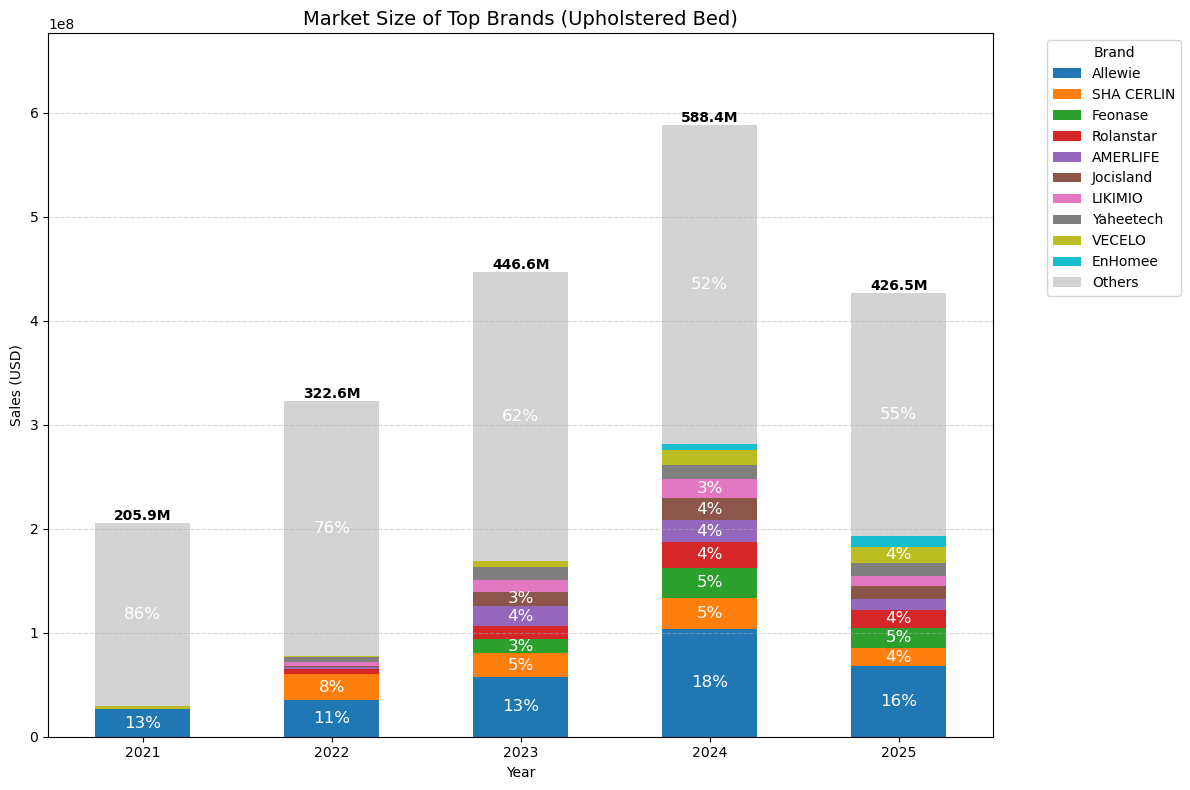

In [178]:
# 6-1. 브랜드별 총매출 합계 기준 내림차순
brand_totals = pivot_top10.sum(axis=0).sort_values(ascending=False)

# 6-2. Others를 맨 위로
if "Others" in brand_totals.index:
    brand_order = brand_totals.drop("Others").index.tolist() + ["Others"]
else:
    brand_order = brand_totals.index.tolist()

pivot_top10 = pivot_top10[brand_order]

# 7. 색상 지정 (Others = 회색)
colors = plt.cm.tab10.colors  # 기본 colormap에서 10개 색상
brand_colors = {b: colors[i % len(colors)] for i, b in enumerate(brand_order)}
if "Others" in brand_colors:
    brand_colors["Others"] = "lightgrey"

# 8. 누적 막대그래프
ax = pivot_top10.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 8),
    color=[brand_colors[b] for b in pivot_top10.columns]
)

plt.title("Market Size of Top Brands (Upholstered Bed)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Sales (USD)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# ✅ 범례 표시 (Others 포함)
plt.legend(title="Brand", bbox_to_anchor=(1.05, 1), loc='upper left')

# ---------- 여기부터 추가: 비중(%) + 상단 총매출(M) 표기 ----------
# 연도(행)별 총매출
totals_per_year = pivot_top10.sum(axis=1)

# 상단 라벨이 잘 보이도록 여유공간 확보
ax.set_ylim(0, totals_per_year.max() * 1.15)

for i, idx in enumerate(pivot_top10.index):
    row = pivot_top10.loc[idx]
    total = totals_per_year.loc[idx]

    # 총매출이 0이면 스킵
    if total == 0:
        continue

    cum = 0.0
    for b in pivot_top10.columns:
        val = float(row[b]) if pd.notna(row[b]) else 0.0
        if val <= 0:
            continue

        share = val / total  # 비중 (0~1)
        y_center = cum + val / 2.0

        # 구간이 충분히 클 때는 구간 중앙에 흰색으로 %, 작으면 구간 위에 검정으로 표시
        if share >= 0.03:  # 6% 이상이면 내부에 표시
            ax.text(
                i, y_center, f"{share:.0%}",
                ha="center", va="center",
                fontsize=12, color="white"
            )
            
        cum += val

    # 막대 상단에 연도 총매출(Million) 라벨
    ax.text(
        i, total, f"{total/1_000_000:.1f}M",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold"
    )
# ---------- 추가 끝 ----------

plt.tight_layout()
plt.show()

#### - Brand별 SKU 수, 1p/3p

In [183]:
df2 = df_uphols.copy()
df2['year'] = df2['yr_month'].str[:2].astype(int) + 2000
df2.fillna({'RetailSales': 0})

,RetailerSku,gpt_financial_category,gpt_sub_category,gpt_style_type,rf_categories_flat,rf_category,stck_category,bw_ff_type,brand,Title,...,RetailSales,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month,year
0,B08L6D1M7P,20.PLATFORM BEDS,Upholstered PB,None,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,05. Bed Frames,None,VECELO,14 Inch Premium Upholstered Platform Bed Frame...,...,122.43,1,122.43,21-4,21-11,Y21 W45,Y21 W45,29131231.80,687484.66,2021
1,B08L6D1M7P,20.PLATFORM BEDS,Upholstered PB,None,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,05. Bed Frames,None,VECELO,14 Inch Premium Upholstered Platform Bed Frame...,...,367.29,3,122.43,21-2,21-05,Y21 W19,Y21 W19,29131231.80,687484.66,2021
2,B00ASQ4Z3O,20.PLATFORM BEDS,Upholstered PB,None,Home & Kitchen > Furniture > Bedroom Furniture...,Beds,06. Beds,None,247SHOPATHOME,24/7 Shop at Home Kaylin Traditional Tufted He...,...,2060.00,1,2060.00,23-2,23-06,Y23 W23,Y23 W23,258875.84,2131.66,2023
3,B0CGZWDML8,20.PLATFORM BEDS,Upholstered PB,Storage,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,06. Beds,3p,Merax,"3-Pieces Bedroom Sets, Harper & Bright Designs...",...,0.00,0,0.00,24-1,24-01,Y24 W02,Y24 W02,71865984.24,12781118.83,2024
4,B0BPPLZVRH,20.PLATFORM BEDS,Upholstered PB,Storage,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,06. Beds,None,4 EVER WINNER,4 EVER WINNER Bed Frame Full Size Upholstered ...,...,1539.89,11,139.99,22-4,22-12,Y22 W52,Y22 W52,2466381.58,13247.14,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
626619,B0F1TMJ7D7,20.PLATFORM BEDS,Upholstered PB,Storage,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,06. Beds,3p,iPormis,iPormis King Size Bed Frame with 4 Storage Dra...,...,620.97,3,206.99,25-3,25-09,Y25 W37,Y25 W37,45664711.80,8171285.14,2025
626620,B0C7LG23JZ,20.PLATFORM BEDS,Upholstered PB,Storage,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,06. Beds,3p,iPormis,iPormis King Size Bed Frame with 4 Storage Dra...,...,689.97,3,229.99,25-3,25-09,Y25 W37,Y25 W37,45664711.80,8171285.14,2025
626621,B0DGGT98PJ,20.PLATFORM BEDS,Upholstered PB,Wingback,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,06. Beds,3p,iPormis,"iPormis Twin Bed Frame with 3 Storage Drawers,...",...,1299.87,13,99.99,25-3,25-09,Y25 W37,Y25 W37,45664711.80,8171285.14,2025
626622,B0CKRWRH26,20.PLATFORM BEDS,Upholstered PB,None,Home & Kitchen > Furniture > Bedroom Furniture...,Bed Frames,06. Beds,3p,iPormis,iPormis Twin Size Metal Bed Frame with Linen U...,...,119.96,2,59.98,25-3,25-09,Y25 W37,Y25 W37,45664711.80,8171285.14,2025


In [187]:
# 3) Filter: WeekId >= 202401
df_2025 = df1[df1['year'] == 2025].copy()

# 4) Aggregate by brand
brand_stats = (
    df_2025.groupby('brand')
               .agg(TotalSales=('RetailSales', 'sum'),
                    UniqueASINs=('RetailerSku', 'nunique'))
               .reset_index()
               .sort_values('TotalSales', ascending=False)
               .reset_index(drop=True)
)

print(brand_stats.head(20))   # Top 20 rows

         brand   TotalSales  UniqueASINs
0      Allewie  68218246.75          378
1      Feonase  19924423.46          354
2    Rolanstar  16833714.35          124
3   SHA CERLIN  16801895.22          330
4       VECELO  15141121.36          869
5    Jocisland  12344430.09          272
6    Yaheetech  12262191.05           95
7     AMERLIFE  10560678.57          252
8      EnHomee  10324416.44           90
9      LIKIMIO  10307277.14          131
10     Einhomn   9272034.45          252
11     iPormis   9224362.81          180
12    Furnulem   8786374.25           17
13      Keyluv   7274080.88          138
14     LARMACE   7152292.18           92
15       Zinus   6982039.83          104
16   BarnFurin   6493834.96          250
17    YITAHOME   6347308.83          572
18      HOMBCK   5870347.51          215
19    Koorlian   5825872.05           53


In [191]:
# bw_ff_type NaN → "NULL"
df_2025['bw_ff_type_filled'] = (
    df_2025['bw_ff_type']
        .astype('string')
        .str.strip()
        .str.upper()
        .fillna('NULL')
)

# 4) Aggregate by brand
brand_stats = (
    df_2025.groupby('brand')
               .agg(TotalSales=('RetailSales', 'sum'),
                    TotalQty=('UnitsSold', 'sum'),
                    UniqueASINs=('RetailerSku', 'nunique'))
               .reset_index()
)

# 5) Sales Share (%)
total_sales_sum = brand_stats['TotalSales'].sum()
brand_stats['SalesShare'] = brand_stats['TotalSales'] / total_sales_sum * 100

# 6) Unique ASIN count by bw_ff_type
bw_counts = (
    df_2025.groupby(['brand','bw_ff_type_filled'])['RetailerSku']
               .nunique()
               .unstack(fill_value=0)
               .reset_index()
)

for col in ['1P','2P','3P','NULL']:
    if col not in bw_counts.columns:
        bw_counts[col] = 0

bw_counts = bw_counts.rename(columns={
    '1P':'1P_unique',
    '2P':'2P_unique',
    '3P':'3P_unique',
    'NULL':'NULL_unique'
})

# 7) Merge
brand_stats = brand_stats.merge(bw_counts, on='brand', how='left')

# 8) 컬럼 순서 재배치: TotalSales → SalesShare → UniqueASINs ...
cols = ['brand','TotalSales','TotalQty', 'SalesShare','UniqueASINs',
        '1P_unique','2P_unique','3P_unique','NULL_unique']
brand_stats = brand_stats[cols]

# 9) 정렬 (매출 기준)
brand_stats = brand_stats.sort_values('TotalSales', ascending=False).reset_index(drop=True)

brand_stats.head(20)

,brand,TotalSales,TotalQty,SalesShare,UniqueASINs,1P_unique,2P_unique,3P_unique,NULL_unique
0,Allewie,68218246.75,386490,15.996118,378,221,0,128,29
1,Feonase,19924423.46,114784,4.671967,354,128,3,34,189
2,Rolanstar,16833714.35,95319,3.947244,124,86,0,16,22
3,SHA CERLIN,16801895.22,95660,3.939783,330,159,0,149,22
4,VECELO,15141121.36,113921,3.550358,869,516,11,18,324
5,Jocisland,12344430.09,39056,2.894577,272,0,0,167,105
6,Yaheetech,12262191.05,89597,2.875293,95,9,0,53,33
7,AMERLIFE,10560678.57,29697,2.476315,252,0,0,173,79
8,EnHomee,10324416.44,54422,2.420915,90,0,0,70,20
9,LIKIMIO,10307277.14,71982,2.416896,131,34,0,33,64


In [57]:
df1 = df_adjustable.copy()

## (old) Price 분석 

#### Bed Totals 부분

In [12]:
df_total_beds = df_beds_bedframes.copy()

In [14]:
df_total_beds['RetailerSku'].nunique()

147159

In [16]:
print(df_total_beds)

         RetailerId RetailerName RetailerSku           upc  \
0                 1   Amazon.com  B0046167BU  2.954943e+10   
1                 1   Amazon.com  B01195ZBIU  6.361734e+11   
2                 1   Amazon.com  B07HVV39BF           NaN   
3                 1   Amazon.com  B07YDCH55W           NaN   
4                 1   Amazon.com  B07D4BD47F           NaN   
...             ...          ...         ...           ...   
2649509           1   Amazon.com  B0CD1XJJJL           NaN   
2649510           1   Amazon.com  B0B49W9VVM           NaN   
2649511           1   Amazon.com  B0CKW3LV3D           NaN   
2649512           1   Amazon.com  B0C73SQCJZ           NaN   
2649513           1   Amazon.com  B0CNK3H58W           NaN   

                             ModelNumber  \
0                             129*F43324   
1                                   None   
2                                   None   
3                                   None   
4                          AMZ-7ADS

In [18]:
# WeekId 앞 4자리로 year 추출
df_total_beds['year'] = df_total_beds['WeekId'].astype(str).str[:4].astype(int)

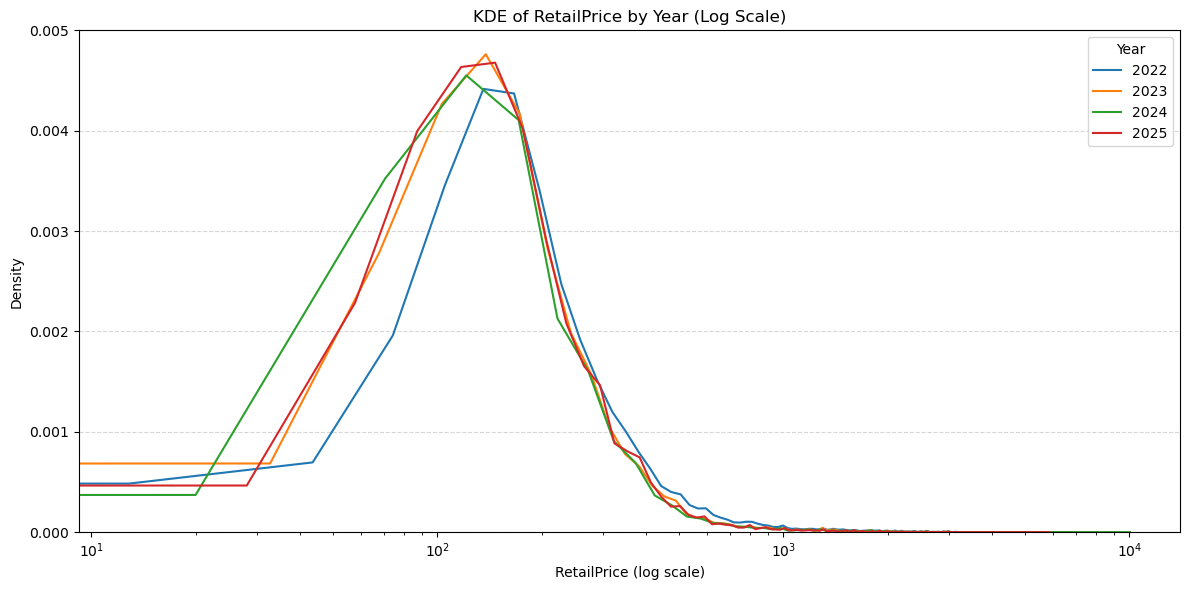

In [54]:
#df_filtered = df_total_beds[df_total_beds['RetailPrice'] > 0].copy()
# 2022~2025년 데이터만 포함 & RetailPrice > 0
df_filtered = df_total_beds[(df_total_beds['year'].between(2022, 2025)) & (df_total_beds['RetailPrice'] > 0)].copy()

plt.figure(figsize=(12, 6))

for year in sorted(df_filtered['year'].unique()):
    prices = df_filtered.loc[df_filtered['year'] == year, 'RetailPrice'].dropna()
    if not prices.empty:
        sns.kdeplot(prices, label=str(year), bw_adjust=0.7)

plt.xscale('log')  # ✅ x축 로그 변환
plt.xlabel("RetailPrice (log scale)")
plt.ylabel("Density")
plt.title("KDE of RetailPrice by Year (Log Scale)")
plt.legend(title="Year")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

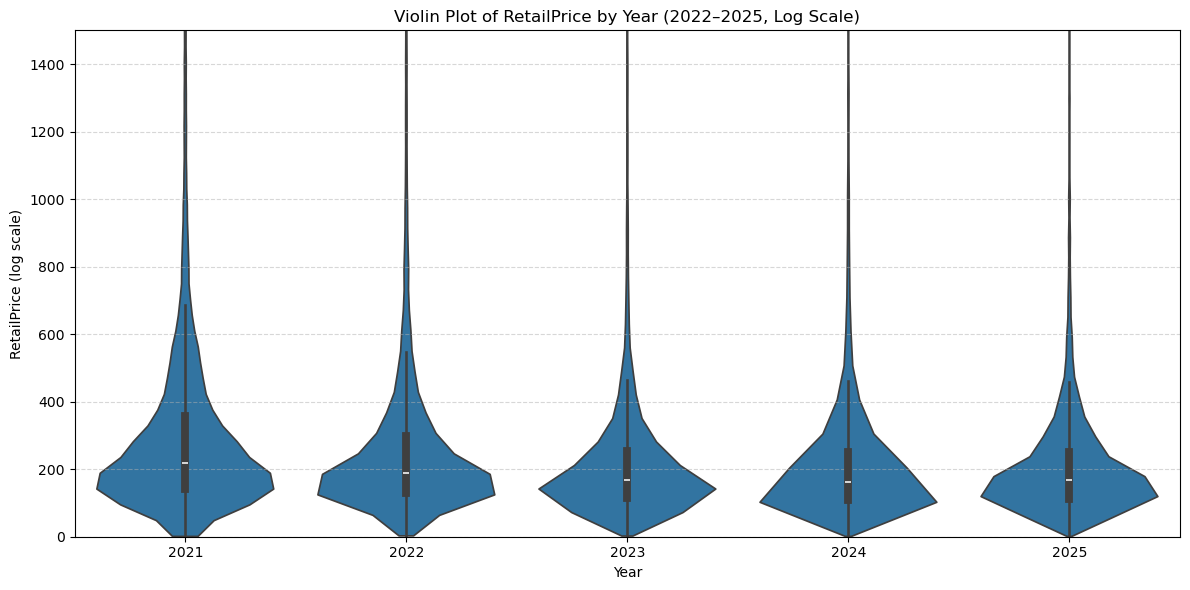

In [50]:
#df_filtered = df_total_beds[df_total_beds['RetailPrice'] > 0].copy()
df_filtered = df_total_beds[(df_total_beds['year'].between(2021, 2025)) & (df_total_beds['RetailPrice'] > 0)].copy()

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_filtered, 
    x="year", 
    y="RetailPrice", 
    cut=0, 
    density_norm="width"   # ✅ scale 대신 density_norm 사용
)

#plt.yscale('log')  # ✅ y축 로그 변환 (RetailPrice 축)
plt.ylim(0, 1500)   # ✅ y축 0 ~ 5000까지만 표시
plt.xlabel("Year")
plt.ylabel("RetailPrice (log scale)")
plt.title("Violin Plot of RetailPrice by Year (2022–2025, Log Scale)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

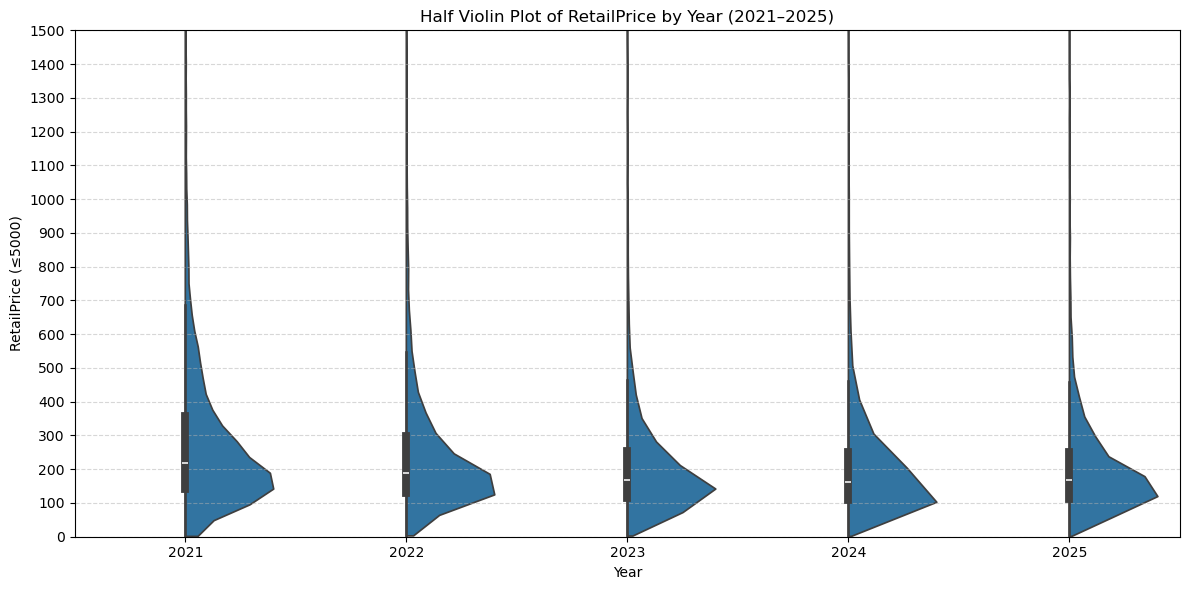

In [62]:
df_filtered = df_total_beds[(df_total_beds['year'].between(2021, 2025)) & 
                            (df_total_beds['RetailPrice'] > 0)].copy()

plt.figure(figsize=(12, 6))

# 기본 violinplot
ax = sns.violinplot(
    data=df_filtered, 
    x="year", 
    y="RetailPrice", 
    cut=0, 
    density_norm="width",
    inner="box"   # ✅ Box 포함
)

# Half violin (오른쪽 절반만 남기기)
for c in ax.collections:
    paths = c.get_paths()
    for p in paths:
        v = p.vertices
        mean_x = (v[:, 0].max() + v[:, 0].min()) / 2
        v[:, 0] = np.clip(v[:, 0], mean_x, 1e9)   # 왼쪽 잘라내기 → 오른쪽만 표시

# ✅ Y축 0~5000 제한 + 100 단위 눈금
plt.ylim(0, 1500)
ax.yaxis.set_major_locator(MultipleLocator(100))

plt.xlabel("Year")
plt.ylabel("RetailPrice (≤5000)")
plt.title("Half Violin Plot of RetailPrice by Year (2021–2025)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

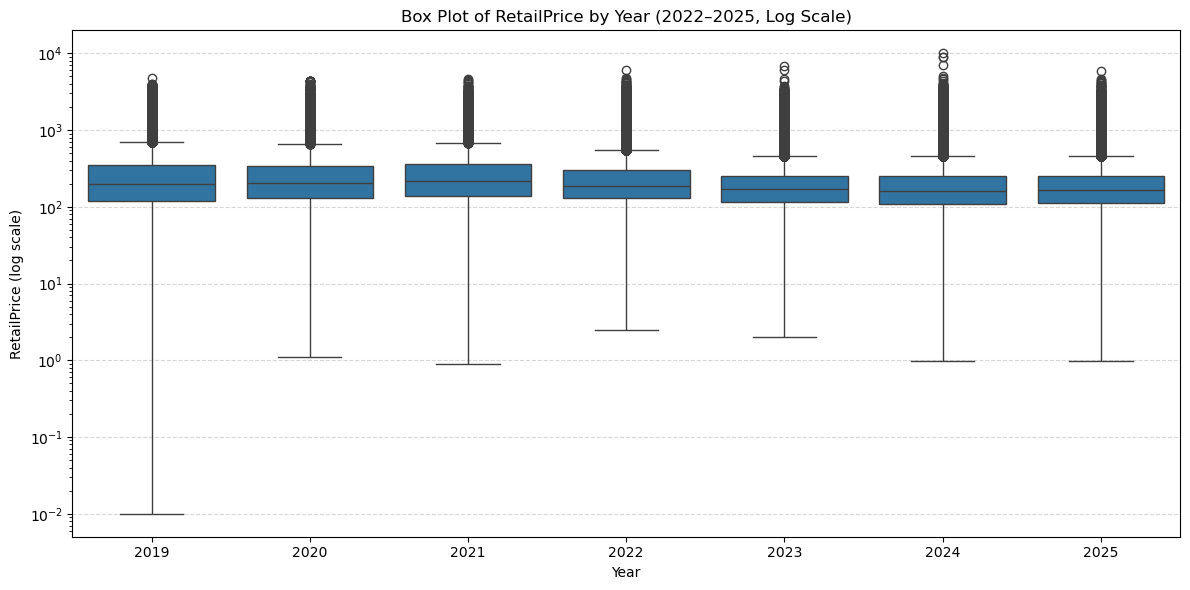

In [38]:
df_filtered = df_total_beds[df_total_beds['RetailPrice'] > 0].copy()
# df_filtered = df_total_beds[(df_total_beds['year'].between(2022, 2025)) & 
#                             (df_total_beds['RetailPrice'] > 0)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtered, x="year", y="RetailPrice")

plt.yscale('log')  # ✅ y축 로그 변환 (RetailPrice 축)
plt.xlabel("Year")
plt.ylabel("RetailPrice (log scale)")
plt.title("Box Plot of RetailPrice by Year (2022–2025, Log Scale)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

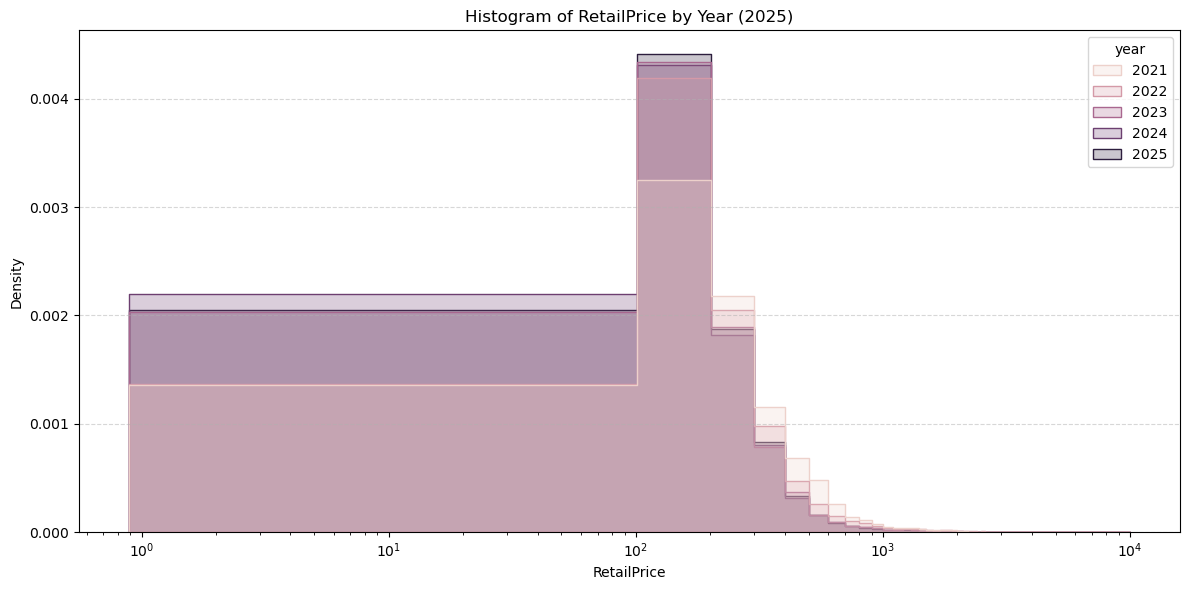

In [34]:
#df_filtered = df_total_beds[df_total_beds['RetailPrice'] > 0].copy()
df_filtered = df_total_beds[(df_total_beds['year'].between(2021, 2025)) & (df_total_beds['RetailPrice'] > 0)].copy()

plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_filtered, 
    x="RetailPrice", 
    hue="year", 
    element="step", 
    stat="density", 
    common_norm=False,
    bins=100
)
plt.xscale("log")   # ✅ 로그 변환
plt.xlabel("RetailPrice")
plt.ylabel("Density")
plt.title("Histogram of RetailPrice by Year (2025)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Adjustable 부분만  

In [74]:
df_adjustable = df[df['last_category']=='Adjustable Bases'].copy()

In [80]:
# WeekId 앞 4자리로 year 추출 (숫자 아닌 값은 NaN 처리)
df_adjustable['year'] = (
    df_adjustable['WeekId']
    .astype(str)                 # 문자열 변환
    .str[:4]                     # 앞 4자리 추출
    .where(lambda x: x.str.isnumeric())  # 숫자가 아닌 값은 NaN
)


In [82]:
print(df_adjustable)

              asin                                              title  \
1797    B074LGTDSH  S-Cape 2.0 Leggett and Platt Adjustable Bed Ba...   
1917    B0DGGN6THK  Adjustable Bed Frame Queen with 4-Level Height...   
1918    B0DGGP822P  Twin XL Adjustable Bed Frame, Adjustable Bed B...   
1991    B07FCW9T6H  Blissful Nights Split King e4 Adjustable Bed B...   
1992    B07FCW9T6H  Blissful Nights Split King e4 Adjustable Bed B...   
...            ...                                                ...   
272750  B08LX9FD8Q  Naomi Home Serenity Split King Adjustable Bed ...   
272751  B08LX9FD8Q  Naomi Home Serenity Split King Adjustable Bed ...   
272752  B08LX9FD8Q  Naomi Home Serenity Split King Adjustable Bed ...   
272753  B08LX9FD8Q  Naomi Home Serenity Split King Adjustable Bed ...   
272754  B08LX9FD8Q  Naomi Home Serenity Split King Adjustable Bed ...   

                                                 keywords            brand  \
1797    S-Cape,2.0,Leggett,and,Platt,Adjustab

In [88]:
# year가 NaN인 행 필터링
df_nan_year = df_adjustable[df_adjustable['year'].isna()]
# 유니크한 ASIN 개수 구하기 (RetailerSku 기준)
unique_asin_count = df_nan_year['asin'].nunique()
print(unique_asin_count)

465


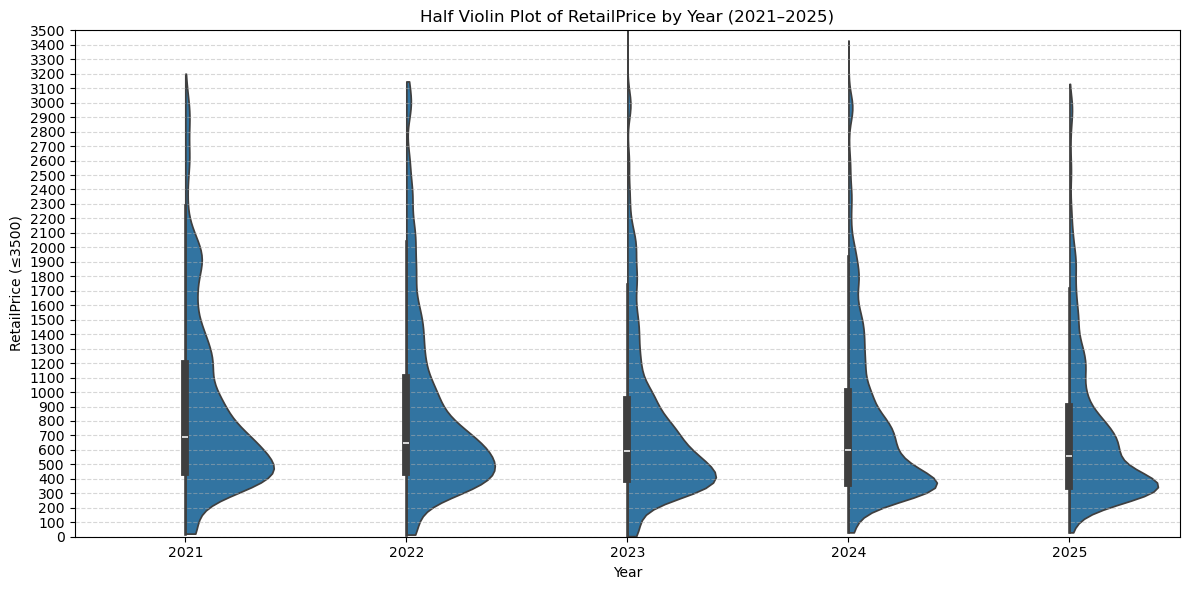

In [120]:
# 1) year 정리 + 필터
df_plot = df_adjustable.copy()
df_plot['year'] = pd.to_numeric(df_plot['year'], errors='coerce')
df_plot = df_plot[df_plot['year'].between(2021, 2025) & (df_plot['RetailPrice'] > 0)]

# 2) 라벨은 문자열, 순서는 정수 기준 오름차순
df_plot['year'] = df_plot['year'].astype(int).astype(str)
years_order = sorted(df_plot['year'].unique(), key=int)   # ✅ x축 순서 지정

# 3) Violin + Half(오른쪽만)
plt.figure(figsize=(12, 6))
ax = sns.violinplot(
    data=df_plot,
    x="year", y="RetailPrice",
    order=years_order,        # ✅ 명시적 정렬
    cut=0,
    density_norm="width",
    inner="box"
)

# 반쪽(오른쪽)만 남기기
for c in ax.collections:
    for p in c.get_paths():
        v = p.vertices
        mid = (v[:, 0].max() + v[:, 0].min()) / 2
        v[:, 0] = np.clip(v[:, 0], mid, 1e9)

# 축/그리드
ax.set_ylim(0, 3500)                          # 필요시 5000 등으로 조정
ax.yaxis.set_major_locator(MultipleLocator(100))
ax.set_xlabel("Year")
ax.set_ylabel("RetailPrice (≤3500)")
ax.set_title("Half Violin Plot of RetailPrice by Year (2021–2025)")
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Top 10 Brands (2024–2025) — Sales Sum & RetailPrice Median
                     sales_sum_fmt price_median_fmt
brand                                              
Sven & Son             $40,025,990           $1,495
Best Choice Products   $14,665,637             $500
ESHINE                 $13,849,708             $850
LUCID                  $11,680,673             $475
Marsail                 $9,891,677             $405
Blissful Nights         $6,109,860             $699
GOLDORO                 $5,718,007             $340
Dyonery                 $3,866,865             $799
Nestl                   $3,727,437             $679
Nectar                  $3,532,268             $699


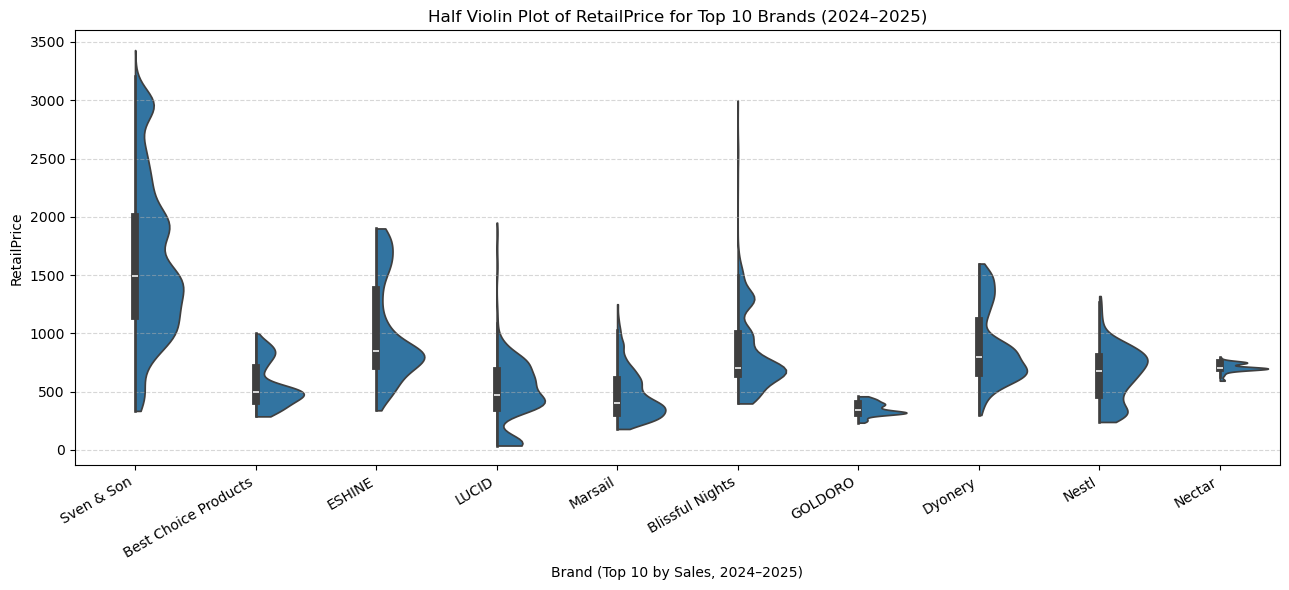

In [154]:
# ===== 데이터 소스 선택 =====
# 필요 시 df_total_beds 로 변경 가능
df_src = df_adjustable.copy()

# ===== year 확보 및 2024~2025 제한 =====
if 'year' in df_src.columns:
    df_src['year'] = pd.to_numeric(df_src['year'], errors='coerce')
elif 'WeekId' in df_src.columns:
    df_src['year'] = pd.to_numeric(df_src['WeekId'].astype(str).str[:4], errors='coerce')
else:
    raise KeyError("year 또는 WeekId 컬럼이 필요합니다.")

df_src = df_src[df_src['year'].between(2024, 2025)]

# ===== 전처리 =====
df_src['RetailPrice'] = pd.to_numeric(df_src['RetailPrice'], errors='coerce')
df_src['RetailSales'] = pd.to_numeric(df_src['RetailSales'], errors='coerce')
df_src['brand']       = df_src['brand'].astype(str)

df_clean = df_src[(df_src['RetailPrice'] > 0) & df_src['RetailSales'].notna()].copy()

# ===== 브랜드별 매출 합계 & Top10 선정 (2024~2025 범위 내) =====
brand_sales = (
    df_clean.groupby('brand', dropna=True)['RetailSales']
            .sum()
            .sort_values(ascending=False)
            .head(10)
)
top10 = brand_sales.index.tolist()

# ===== Top10 요약표: 매출합 + RetailPrice 중위수 =====
summary = (
    df_clean[df_clean['brand'].isin(top10)]
    .groupby('brand', as_index=True)
    .agg(
        sales_sum=('RetailSales', 'sum'),
        price_median=('RetailPrice', 'median')
    )
    .reindex(top10)  # 매출 순서 유지
)

# 보기 좋은 포맷 출력
print("Top 10 Brands (2024–2025) — Sales Sum & RetailPrice Median")
print(
    summary.assign(
        sales_sum_fmt=lambda d: d['sales_sum'].map(lambda x: f"${x:,.0f}"),
        price_median_fmt=lambda d: d['price_median'].map(lambda x: f"${x:,.0f}")
    )[["sales_sum_fmt", "price_median_fmt"]]
)

# ===== Half Violin Plot (오른쪽 반쪽) =====
plot_df = df_clean[df_clean['brand'].isin(top10)].copy()

plt.figure(figsize=(13, 6))
ax = sns.violinplot(
    data=plot_df,
    x='brand', y='RetailPrice',
    order=top10,           # 매출 순서대로
    cut=0,
    density_norm='width',  # seaborn>=0.15
    inner='box'
)

# 오른쪽 절반만 남기기
for coll in ax.collections:
    for path in getattr(coll, "get_paths", lambda: [])():
        v = path.vertices
        mid = (v[:, 0].max() + v[:, 0].min()) / 2
        v[:, 0] = np.clip(v[:, 0], mid, 1e9)

ax.set_xlabel("Brand (Top 10 by Sales, 2024–2025)")
ax.set_ylabel("RetailPrice")
ax.set_title("Half Violin Plot of RetailPrice for Top 10 Brands (2024–2025)")
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

#### Adjustable + Beds Totals

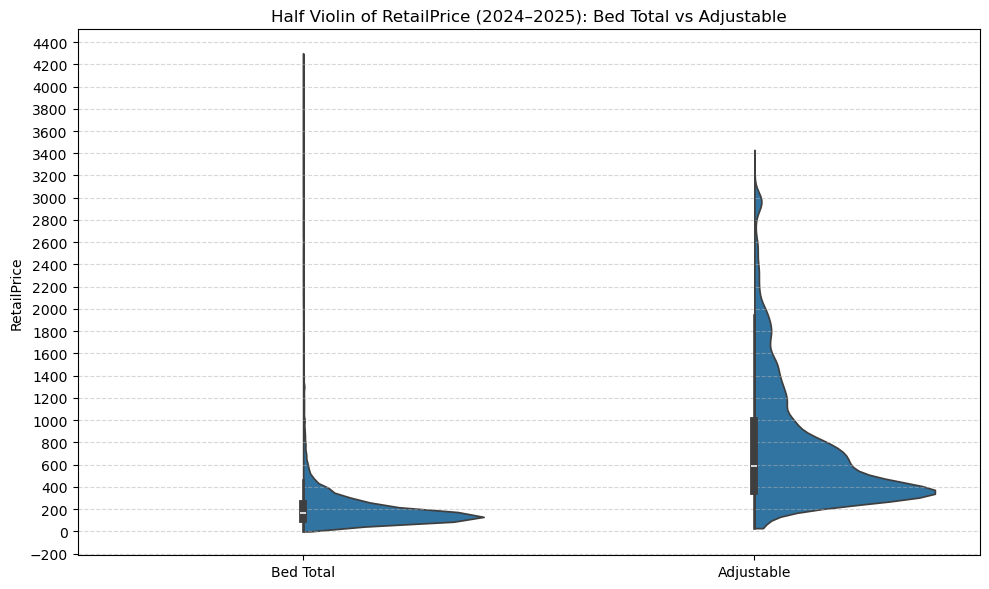

In [129]:

def ensure_year(df, year_col="year", weekid_col="WeekId"):
    d = df.copy()
    if year_col in d.columns:
        d[year_col] = pd.to_numeric(d[year_col], errors="coerce")
    elif weekid_col in d.columns:
        d[year_col] = pd.to_numeric(d[weekid_col].astype(str).str[:4], errors="coerce")
    else:
        raise KeyError("Need 'year' or 'WeekId' column.")
    return d

def filter_yr_price(df, years=(2024, 2025), price_col="RetailPrice", year_col="year",
                    pcap=None, max_n=150_000):
    d = df[(df[year_col].between(years[0], years[1])) & (df[price_col] > 0)].copy()
    if (pcap is not None) and (len(d) > 0):
        thr = np.percentile(d[price_col], pcap)
        d = d[d[price_col] <= thr]
    if (max_n is not None) and (len(d) > max_n):
        d = d.sample(n=max_n, random_state=42)
    return d

# --- 준비
beds = ensure_year(df_total_beds)
adj  = ensure_year(df_adjustable)

# ✅ Bed Total: 범위 제한/컷 없음
beds_f = filter_yr_price(beds, years=(2024, 2025), pcap=None)

# Adjustable: 상위 99%까지만(원하면 pcap=None로 변경)
adj_f  = filter_yr_price(adj,  years=(2024, 2025), pcap=None)

# 결합 (x축 두 카테고리만)
beds_f = beds_f.assign(group="Bed Total")
adj_f  = adj_f.assign(group="Adjustable")
plot_df = pd.concat(
    [beds_f[['group', 'RetailPrice']], adj_f[['group', 'RetailPrice']]],
    ignore_index=True
)

# --- 그리기
plt.figure(figsize=(10, 6))
ax = sns.violinplot(
    data=plot_df,
    x="group", y="RetailPrice",
    order=["Bed Total", "Adjustable"],
    cut=0, density_norm="width", inner="box"
)

# Half violin: 오른쪽 절반만 남기기
for coll in ax.collections:
    for path in getattr(coll, "get_paths", lambda: [])():
        v = path.vertices
        mid = (v[:, 0].max() + v[:, 0].min()) / 2
        v[:, 0] = np.clip(v[:, 0], mid, 1e9)

# ✅ y축을 200 단위로 표시
ax.yaxis.set_major_locator(MultipleLocator(200))

# 축/레이블
ax.set_xlabel("")                 # x축 라벨 제거 (두 카테고리만 보이게)
ax.set_ylabel("RetailPrice")      # ✅ ylim 설정 안 함 → Bed Total 범위 그대로 표시
ax.set_title("Half Violin of RetailPrice (2024–2025): Bed Total vs Adjustable")
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

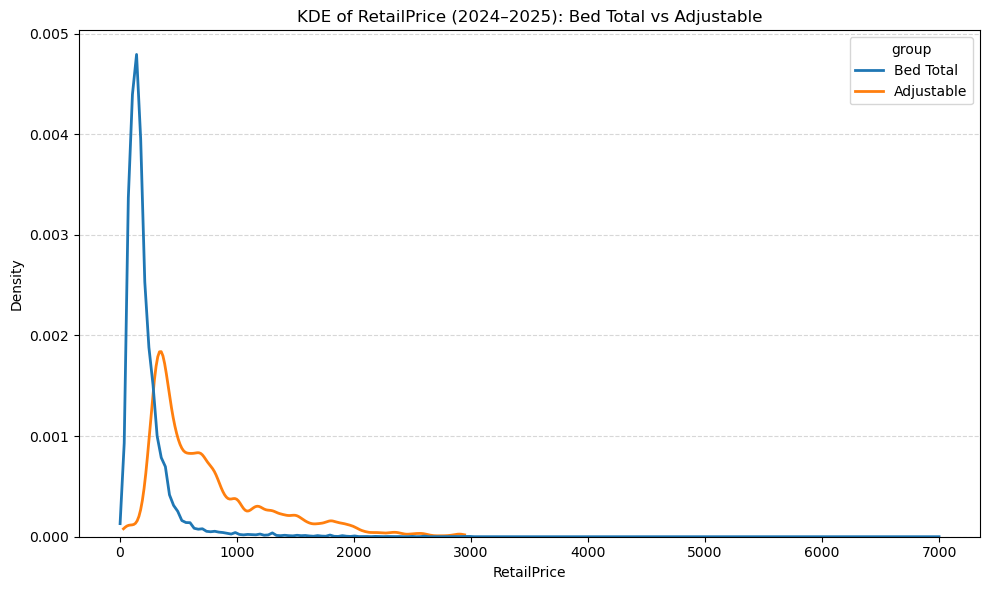

In [131]:
def ensure_year(df, year_col="year", weekid_col="WeekId"):
    d = df.copy()
    if year_col in d.columns:
        d[year_col] = pd.to_numeric(d[year_col], errors="coerce")
    elif weekid_col in d.columns:
        d[year_col] = pd.to_numeric(d[weekid_col].astype(str).str[:4], errors="coerce")
    else:
        raise KeyError("Need 'year' or 'WeekId' column.")
    return d

def filter_yr_price(df, years=(2024, 2025), price_col="RetailPrice", year_col="year",
                    pcap=None, max_n=200_000):
    d = df[(df[year_col].between(years[0], years[1])) & (df[price_col] > 0)].copy()
    if (pcap is not None) and (len(d) > 0):
        thr = np.percentile(d[price_col], pcap)
        d = d[d[price_col] <= thr]
    if (max_n is not None) and (len(d) > max_n):  # 속도 개선용 샘플링
        d = d.sample(n=max_n, random_state=42)
    return d

# --- 데이터 준비
beds = ensure_year(df_total_beds)
adj  = ensure_year(df_adjustable)

beds_f = filter_yr_price(beds, years=(2024, 2025), pcap=None)  # Bed Total: 제한 없음
adj_f  = filter_yr_price(adj,  years=(2024, 2025), pcap=99)    # Adjustable: 99% 컷 (원하면 None)

# 결합 (두 그룹만)
beds_f = beds_f.assign(group="Bed Total")
adj_f  = adj_f.assign(group="Adjustable")
plot_df = pd.concat(
    [beds_f[['group', 'RetailPrice']], adj_f[['group', 'RetailPrice']]],
    ignore_index=True
)

# --- KDE 플롯 (한 장에 두 곡선)
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=plot_df,
    x="RetailPrice",
    hue="group",
    common_norm=False,   # 각 그룹 독립 정규화
    bw_adjust=0.7,       # 부드러움 조절
    cut=0,               # 음수 영역 확장 방지
    fill=False,          # 면채우기 원하면 True
    linewidth=2
)

plt.xlabel("RetailPrice")
plt.ylabel("Density")
plt.title("KDE of RetailPrice (2024–2025): Bed Total vs Adjustable")
plt.grid(axis='y', linestyle='--', alpha=0.5)
# (선택) x축 눈금 200 단위로: 아래 주석 해제
# from matplotlib.ticker import MultipleLocator
# plt.gca().xaxis.set_major_locator(MultipleLocator(200))

plt.tight_layout()
plt.show()

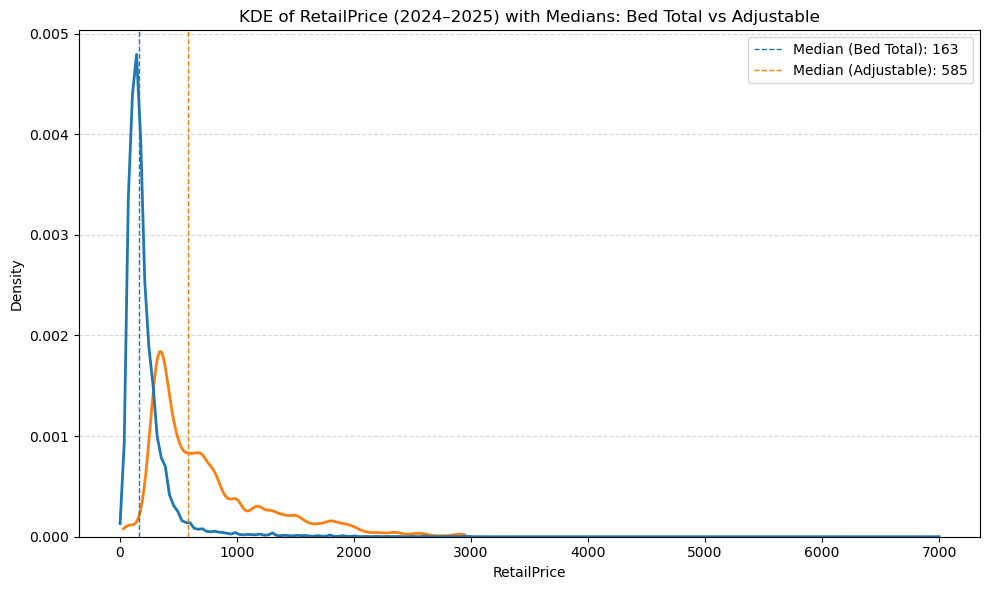

In [138]:
def ensure_year(df, year_col="year", weekid_col="WeekId"):
    d = df.copy()
    if year_col in d.columns:
        d[year_col] = pd.to_numeric(d[year_col], errors="coerce")
    elif weekid_col in d.columns:
        d[year_col] = pd.to_numeric(d[weekid_col].astype(str).str[:4], errors="coerce")
    else:
        raise KeyError("Need 'year' or 'WeekId' column.")
    return d

def filter_yr_price(df, years=(2024, 2025), price_col="RetailPrice", year_col="year",
                    pcap=None, max_n=200_000):
    d = df[(df[year_col].between(years[0], years[1])) & (df[price_col] > 0)].copy()
    if (pcap is not None) and (len(d) > 0):
        thr = np.percentile(d[price_col], pcap)
        d = d[d[price_col] <= thr]
    if (max_n is not None) and (len(d) > max_n):  # 속도 개선용 샘플링
        d = d.sample(n=max_n, random_state=42)
    return d

# --- 데이터 준비
beds = ensure_year(df_total_beds)
adj  = ensure_year(df_adjustable)

beds_f = filter_yr_price(beds, years=(2024, 2025), pcap=None)  # Bed Total: 제한 없음
adj_f  = filter_yr_price(adj,  years=(2024, 2025), pcap=99)    # Adjustable: 99% 컷 (원하면 None)

beds_f = beds_f.assign(group="Bed Total")
adj_f  = adj_f.assign(group="Adjustable")
plot_df = pd.concat(
    [beds_f[['group','RetailPrice']], adj_f[['group','RetailPrice']]],
    ignore_index=True
)

# --- KDE 그리기
plt.figure(figsize=(10, 6))
ax = sns.kdeplot(
    data=plot_df, x="RetailPrice", hue="group",
    hue_order=["Bed Total", "Adjustable"],
    common_norm=False, bw_adjust=0.7, cut=0, fill=False, linewidth=2
)

# --- 그룹별 중위수 계산 & 수직선 표기
med = plot_df.groupby("group")["RetailPrice"].median().to_dict()

palette = sns.color_palette()  # seaborn 기본 팔레트
colormap = {"Bed Total": palette[0], "Adjustable": palette[1]}

for g in ["Bed Total", "Adjustable"]:
    x = med.get(g, None)
    if x is not None and np.isfinite(x):
        ax.axvline(x, linestyle="--", linewidth=1.0, color=colormap[g],
                   label=f"Median ({g}): {x:,.0f}")

# --- 레이아웃
ax.set_xlabel("RetailPrice")
ax.set_ylabel("Density")
ax.set_title("KDE of RetailPrice (2024–2025) with Medians: Bed Total vs Adjustable")
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 범례 정리 (중복 제거)
handles, labels = ax.get_legend_handles_labels()
# 마지막에 추가된 Median 라벨 포함 유지, 중복 제거
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), frameon=True)

plt.tight_layout()
plt.show()

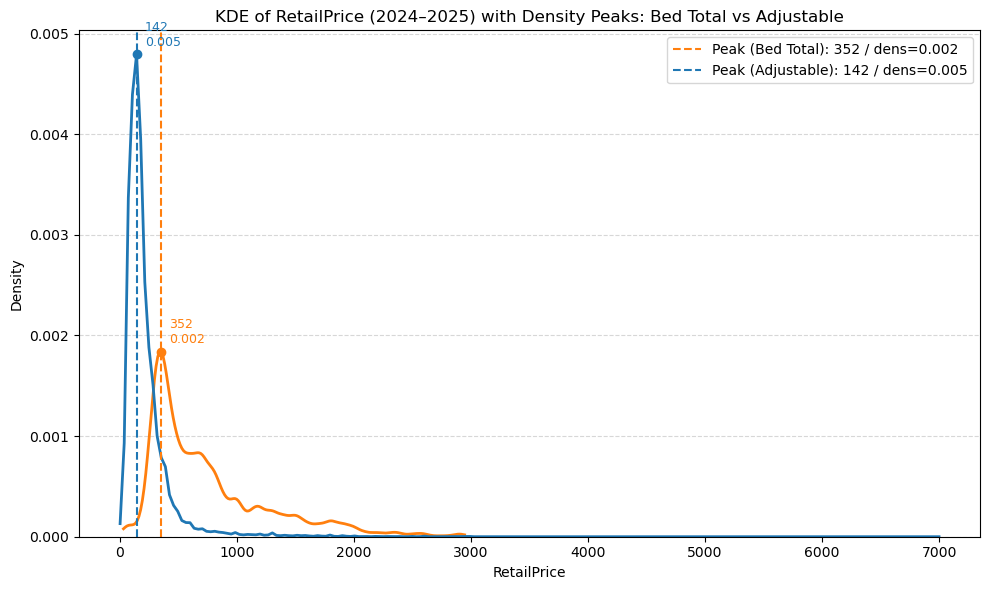

In [144]:

def ensure_year(df, year_col="year", weekid_col="WeekId"):
    d = df.copy()
    if year_col in d.columns:
        d[year_col] = pd.to_numeric(d[year_col], errors="coerce")
    elif weekid_col in d.columns:
        d[year_col] = pd.to_numeric(d[weekid_col].astype(str).str[:4], errors="coerce")
    else:
        raise KeyError("Need 'year' or 'WeekId' column.")
    return d

def filter_yr_price(df, years=(2024, 2025), price_col="RetailPrice", year_col="year",
                    pcap=None, max_n=200_000):
    d = df[(df[year_col].between(years[0], years[1])) & (df[price_col] > 0)].copy()
    if (pcap is not None) and (len(d) > 0):
        thr = np.percentile(d[price_col], pcap)
        d = d[d[price_col] <= thr]
    if (max_n is not None) and (len(d) > max_n):  # 속도 개선용 샘플링
        d = d.sample(n=max_n, random_state=42)
    return d

# --- 데이터 준비
beds = ensure_year(df_total_beds)
adj  = ensure_year(df_adjustable)

beds_f = filter_yr_price(beds, years=(2024, 2025), pcap=None)  # Bed Total: 제한 없음
adj_f  = filter_yr_price(adj,  years=(2024, 2025), pcap=99)    # Adjustable: 99% 컷(원하면 None)

beds_f = beds_f.assign(group="Bed Total")
adj_f  = adj_f.assign(group="Adjustable")
plot_df = pd.concat([beds_f[['group','RetailPrice']], adj_f[['group','RetailPrice']]], ignore_index=True)

# --- KDE 플롯
plt.figure(figsize=(10, 6))
ax = sns.kdeplot(
    data=plot_df, x="RetailPrice", hue="group",
    hue_order=["Bed Total", "Adjustable"],
    common_norm=False, bw_adjust=0.7, cut=0, fill=False, linewidth=2
)

# --- 그룹별 Density Peak(최대 밀도 지점) 계산/표시
# seaborn이 그린 곡선의 (x, y) 데이터를 직접 읽어서 최대 y(밀도) 위치를 찾습니다.
lines = ax.lines[:2]  # fill=False 이므로 각 그룹 1개 라인
groups = ["Bed Total", "Adjustable"]

for g, line in zip(groups, lines):
    x, y = line.get_data()
    if len(x) == 0:
        continue
    i = np.nanargmax(y)             # 최대 밀도 인덱스
    x_peak, y_peak = x[i], y[i]     # 피크 위치 (가격, 밀도)
    c = line.get_color()

    # 피크에 수직선/포인트/라벨 표시
    ax.axvline(x_peak, color=c, linestyle="--", linewidth=1.5, label=f"Peak ({g}): {x_peak:,.0f} / dens={y_peak:.3f}")
    ax.plot([x_peak], [y_peak], marker="o", color=c)
    ax.annotate(f"{x_peak:,.0f}\n{y_peak:.3f}",
                xy=(x_peak, y_peak), xytext=(6, 6), textcoords="offset points",
                color=c, fontsize=9)

# --- 레이아웃
ax.set_xlabel("RetailPrice")
ax.set_ylabel("Density")
ax.set_title("KDE of RetailPrice (2024–2025) with Density Peaks: Bed Total vs Adjustable")
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 범례 중복 제거
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), frameon=True)

plt.tight_layout()
plt.show()

## (old) 1p / 3p 분석

#### - SKU 개수, 1p/3p 비중

In [27]:
df1 = df_adjustable.copy()

In [29]:
df1['asin'].nunique()

2222

In [31]:
df1

,asin,title,keywords,brand,categories_flat,last_category,WeekId,RetailSales,UnitsSold,RetailPrice,weight_num,weight_unit,bw_ff_type,first_available_utc
1711,B074KYTXM2,S-Cape 2.0 Leggett and Platt Adjustable Bed Ba...,"S-Cape,2.0,Leggett,and,Platt,Adjustable,Bed,Ba...",Leggett & Platt,Home & Kitchen > Furniture > Bedroom Furniture...,Adjustable Bases,201918,4599.96,2,2299.98,NaN,None,None,2017-08-05T00:00:00.000Z
1712,B074LGTDSH,S-Cape 2.0 Leggett and Platt Adjustable Bed Ba...,"S-Cape,2.0,Leggett,and,Platt,Adjustable,Bed,Ba...",Leggett & Platt,Home & Kitchen > Furniture > Bedroom Furniture...,Adjustable Bases,201910,4999.96,2,2499.98,NaN,None,None,2017-08-05T00:00:00.000Z
1713,B074LGTDSH,S-Cape 2.0 Leggett and Platt Adjustable Bed Ba...,"S-Cape,2.0,Leggett,and,Platt,Adjustable,Bed,Ba...",Leggett & Platt,Home & Kitchen > Furniture > Bedroom Furniture...,Adjustable Bases,201919,4999.96,2,2499.98,NaN,None,None,2017-08-05T00:00:00.000Z
1714,B074LGTDSH,S-Cape 2.0 Leggett and Platt Adjustable Bed Ba...,"S-Cape,2.0,Leggett,and,Platt,Adjustable,Bed,Ba...",Leggett & Platt,Home & Kitchen > Furniture > Bedroom Furniture...,Adjustable Bases,201907,7499.94,3,2499.98,NaN,None,None,2017-08-05T00:00:00.000Z
1715,B074LGTDSH,S-Cape 2.0 Leggett and Platt Adjustable Bed Ba...,"S-Cape,2.0,Leggett,and,Platt,Adjustable,Bed,Ba...",Leggett & Platt,Home & Kitchen > Furniture > Bedroom Furniture...,Adjustable Bases,201912,2499.98,1,2499.98,NaN,None,None,2017-08-05T00:00:00.000Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272756,B08LX9FD8Q,Naomi Home Serenity Split King Adjustable Bed ...,"Naomi,Home,Serenity,Split,King,Adjustable,Bed,...",Naomi Home,Home & Kitchen > Furniture > Bedroom Furniture...,Adjustable Bases,202215,599.95,1,599.95,NaN,None,3p,None
272757,B08LX9FD8Q,Naomi Home Serenity Split King Adjustable Bed ...,"Naomi,Home,Serenity,Split,King,Adjustable,Bed,...",Naomi Home,Home & Kitchen > Furniture > Bedroom Furniture...,Adjustable Bases,202329,20228.25,35,577.95,NaN,None,3p,None
272758,B08LX9FD8Q,Naomi Home Serenity Split King Adjustable Bed ...,"Naomi,Home,Serenity,Split,King,Adjustable,Bed,...",Naomi Home,Home & Kitchen > Furniture > Bedroom Furniture...,Adjustable Bases,202244,1754.85,3,584.95,NaN,None,3p,None
272759,B08LX9FD8Q,Naomi Home Serenity Split King Adjustable Bed ...,"Naomi,Home,Serenity,Split,King,Adjustable,Bed,...",Naomi Home,Home & Kitchen > Furniture > Bedroom Furniture...,Adjustable Bases,202313,16279.65,27,602.95,NaN,None,3p,None


In [43]:
df1.groupby('bw_ff_type', dropna=False)['asin'].nunique()

bw_ff_type
1p      192
2p       48
3p     1168
NaN     814
Name: asin, dtype: int64

In [45]:
df_2025 = df1[df1['WeekId'] >= 202501]
df_2025.groupby('bw_ff_type', dropna=False)['asin'].nunique()

bw_ff_type
1p     130
2p      33
3p     584
NaN    158
Name: asin, dtype: int64

In [31]:
# 1. WeekId에서 연도 추출
df1['year'] = (
    df1['WeekId']
    .astype(str)                # 문자열 변환
    .str[:4]                    # 앞 4자리 추출
)

# 2. 숫자가 아닌 값은 NaN 처리 후 정수형 변환
df1['year'] = pd.to_numeric(df1['year'], errors='coerce').astype('Int64')

# 3. 연도별 unique asin 개수 집계
year_asin_count = (
    df1.groupby("year")["asin"]
      .nunique()
      .reset_index(name="unique_asin_count")
)

print(year_asin_count)

   year  unique_asin_count
0  2019                275
1  2020                303
2  2021                411
3  2022                450
4  2023                559
5  2024                978
6  2025                905


In [53]:
# bw_ff_type NaN → 'NULL'
df1['bw_ff_type_filled'] = df1['bw_ff_type'].fillna('NULL')

# 1. 연도별 asin 개수
asin_count = (
    df1.groupby('year')['asin']
       .nunique()
       .reset_index(name='asin개수')
)

# 2. 연도별 bw_ff_type별 unique asin 개수
bw_unique_counts = (
    df1.groupby(['year', 'bw_ff_type_filled'])['asin']
       .nunique()
       .unstack(fill_value=0)
       .reset_index()
       .rename(columns={
           '1P': '1p_asin개수',
           '2P': '2p_asin개수',
           '3P': '3p_asin개수',
           'NULL': 'null_asin개수'
       })
)

# 3. 병합
result = asin_count.merge(bw_unique_counts, on='year', how='left')

print(result)

   year  asin개수   1p  2p   3p  null_asin개수
0  2019     275   13   0   75          187
1  2020     303   16   0   98          189
2  2021     411   29   0  148          234
3  2022     450   38   8  187          217
4  2023     559   49  13  248          249
5  2024     978   89  25  503          361
6  2025     905  130  33  584          158


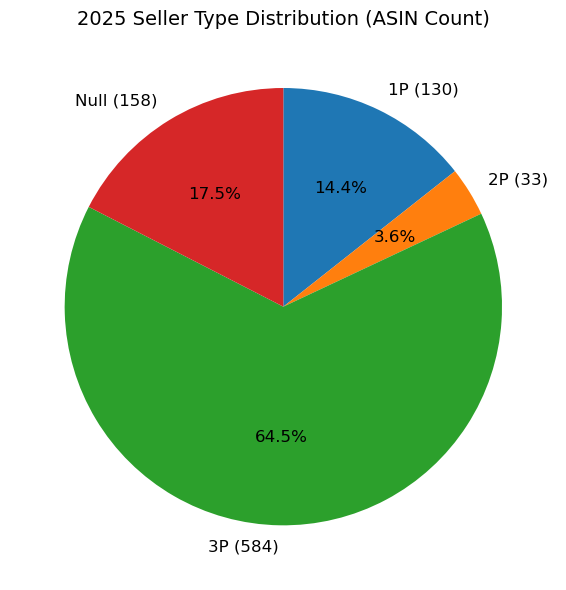

In [33]:
# -------------------------
# 2025년 판매자 유형 데이터 (ASIN 개수)
# -------------------------
data_2025_seller = {
    "1P": 130,
    "2P": 33,
    "3P": 584,
    "Null": 158
}

# 파이차트: 라벨에 "이름 (개수)" 표시, 조각에는 비율 자동 표기
sizes = list(data_2025_seller.values())
labels = [f"{k} ({v})" for k, v in data_2025_seller.items()]

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%.1f%%",
    startangle=90,
    counterclock=False,
    textprops={'fontsize': 12}  # 라벨, 퍼센트 표시 폰트 크기 조정
)
plt.title("2025 Seller Type Distribution (ASIN Count)", fontsize=14)  # 제목 폰트 크기
plt.tight_layout()
plt.show()


[연도별 bw_ff_type별 Unique ASIN 개수]
bw_ff_type_filled  year   1p  2p   3p  null_asin개수
0                  2019   13   0   75          187
1                  2020   16   0   98          189
2                  2021   29   0  148          234
3                  2022   38   8  187          217
4                  2023   49  13  248          249
5                  2024   89  25  503          361
6                  2025  130  33  584          158


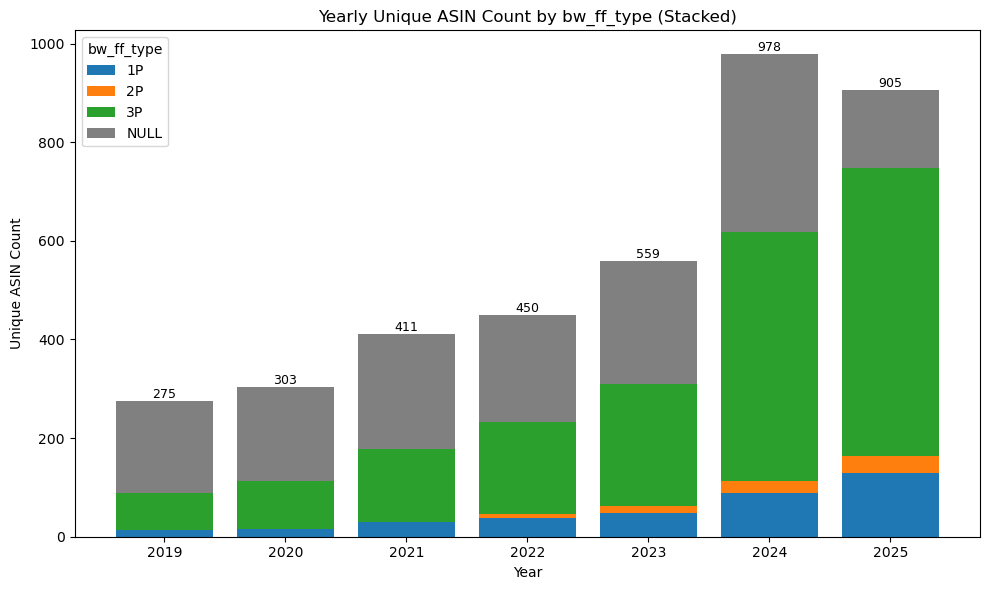

In [79]:

# 0) 안전 복사(경고 방지)
#df = df1.loc[:, ['asin', 'WeekId', 'bw_ff_type']].copy()
df1 = df_adjustable.copy()

# 1) WeekId → year 추출 (숫자 아닌 값은 NaN → 제거)
df1['year'] = pd.to_numeric(df1['WeekId'].astype(str).str[:4], errors='coerce')
df1 = df1.dropna(subset=['year']).copy()
df1['year'] = df1['year'].astype('Int64')  # 결측 허용 정수

# 2) bw_ff_type 정리 (NaN→"NULL", 공백제거, 대문자 통일)
df1['bw_ff_type_filled'] = (
    df1['bw_ff_type']
      .astype('string')
      .str.strip()
      .str.upper()
      .fillna('NULL')
)

# 3) 피벗 테이블: 연도 × bw_ff_type별 unique asin 개수
pivot = (
    df1.groupby(['year', 'bw_ff_type_filled'])['asin']
      .nunique()
      .unstack(fill_value=0)  # 컬럼으로 펼치기
)

# 3-1) 1P/2P/3P/NULL 컬럼이 없더라도 0으로 보장
for col in ['1P', '2P', '3P', 'NULL']:
    if col not in pivot.columns:
        pivot[col] = 0

# 3-2) 연도 정렬 및 표시용 DataFrame 구성
pivot = pivot[['1P', '2P', '3P', 'NULL']].sort_index()
pivot_display = pivot.reset_index().rename(columns={
    '1P': '1p', '2P': '2p', '3P': '3p', 'NULL': 'null_asin개수'
})

print("\n[연도별 bw_ff_type별 Unique ASIN 개수]")
print(pivot_display)

# 4) 일반적인 누적 막대그래프 (1P→2P→3P→NULL 순서로 누적)
years = pivot.index.astype('Int64').astype(str)

s1 = pivot['1P']
s2 = pivot['2P']
s3 = pivot['3P']
s0 = pivot['NULL']
totals = s1 + s2 + s3 + s0

# --- 누적 막대그래프 (NULL만 회색) ---
plt.figure(figsize=(10, 6))

bar1 = plt.bar(years, s1, label='1P')                                   # 기본 색
bar2 = plt.bar(years, s2, bottom=s1, label='2P')                        # 기본 색
bar3 = plt.bar(years, s3, bottom=s1 + s2, label='3P')                   # 기본 색
bar0 = plt.bar(
    years, s0,
    bottom=s1 + s2 + s3,
    label='NULL',
    color='grey'  # ← 여기! NULL을 회색으로
)

totals = s1 + s2 + s3 + s0
for i, tot in enumerate(totals):
    plt.text(i, tot, f'{int(tot):,}', ha='center', va='bottom', fontsize=9)

plt.title('Yearly Unique ASIN Count by bw_ff_type (Stacked)')
plt.xlabel('Year'); plt.ylabel('Unique ASIN Count')
plt.legend(title='bw_ff_type')
plt.tight_layout()
plt.show()


[연도별 bw_ff_type별 Unique ASIN 개수]
bw_ff_type_filled  year   1p  2p   3p  null_asin개수
0                  2019   13   0   75          187
1                  2020   16   0   98          189
2                  2021   29   0  148          234
3                  2022   38   8  187          217
4                  2023   49  13  248          249
5                  2024   89  25  503          361
6                  2025  130  33  584          158


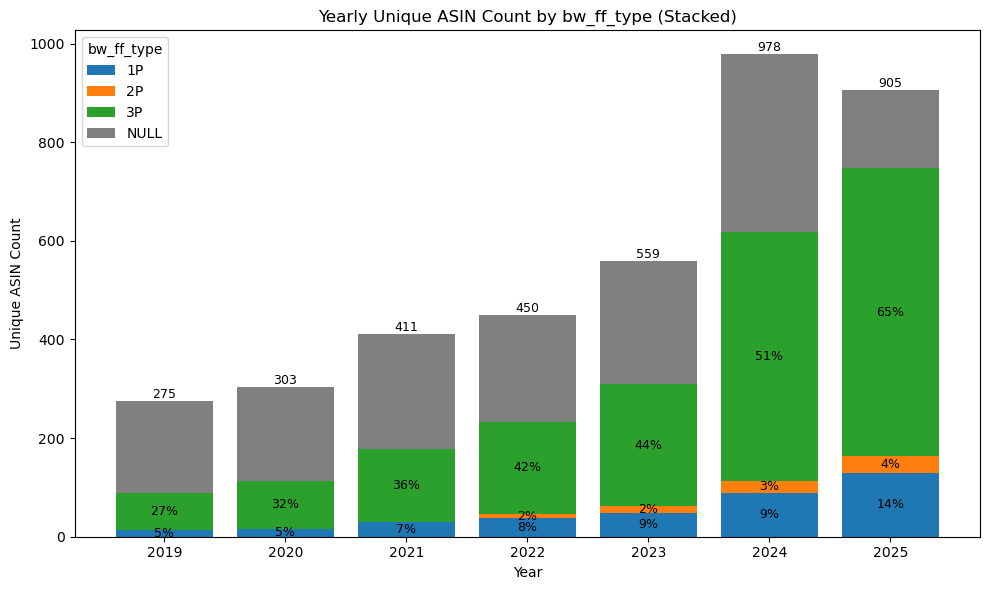

In [81]:
# 0) 안전 복사(경고 방지)
# df1 원본 대신 조정본 사용
df1 = df_adjustable.copy()

# 1) WeekId → year 추출 (숫자 아닌 값은 NaN → 제거)
df1['year'] = pd.to_numeric(df1['WeekId'].astype(str).str[:4], errors='coerce')
df1 = df1.dropna(subset=['year']).copy()
df1['year'] = df1['year'].astype('Int64')  # 결측 허용 정수

# 2) bw_ff_type 정리 (NaN→"NULL", 공백제거, 대문자 통일)
df1['bw_ff_type_filled'] = (
    df1['bw_ff_type']
      .astype('string')
      .str.strip()
      .str.upper()
      .fillna('NULL')
)

# 3) 피벗 테이블: 연도 × bw_ff_type별 unique asin 개수
pivot = (
    df1.groupby(['year', 'bw_ff_type_filled'])['asin']
      .nunique()
      .unstack(fill_value=0)  # 컬럼으로 펼치기
)

# 3-1) 1P/2P/3P/NULL 컬럼이 없더라도 0으로 보장
for col in ['1P', '2P', '3P', 'NULL']:
    if col not in pivot.columns:
        pivot[col] = 0

# 3-2) 연도 정렬 및 표시용 DataFrame 구성
pivot = pivot[['1P', '2P', '3P', 'NULL']].sort_index()
pivot_display = pivot.reset_index().rename(columns={
    '1P': '1p', '2P': '2p', '3P': '3p', 'NULL': 'null_asin개수'
})

print("\n[연도별 bw_ff_type별 Unique ASIN 개수]")
print(pivot_display)

# 4) 일반적인 누적 막대그래프 (1P→2P→3P→NULL 순서로 누적)
years = pivot.index.astype('Int64').astype(str)

s1 = pivot['1P']
s2 = pivot['2P']
s3 = pivot['3P']
s0 = pivot['NULL']
totals = s1 + s2 + s3 + s0

plt.figure(figsize=(10, 6))

# NULL만 회색으로 지정 (나머지는 기본 색상)
bar1 = plt.bar(years, s1, label='1P')
bar2 = plt.bar(years, s2, bottom=s1, label='2P')
bar3 = plt.bar(years, s3, bottom=s1 + s2, label='3P')
bar0 = plt.bar(years, s0, bottom=s1 + s2 + s3, label='NULL', color='grey')

# 막대 상단 합계 라벨
for i, tot in enumerate(totals):
    plt.text(i, tot, f'{int(tot):,}', ha='center', va='bottom', fontsize=9)

# ===== 여기부터 1P/2P/3P 비중(%) 라벨 추가 =====
# (기본) NULL 포함 분모
den = totals.replace(0, np.nan)

# (옵션) NULL 제외 분모로 보고 싶다면 아래 주석을 해제하고 위 den 줄을 주석 처리하세요.
# den = (s1 + s2 + s3).replace(0, np.nan)

p1 = (s1 / den) * 100
p2 = (s2 / den) * 100
p3 = (s3 / den) * 100

# 각 세그먼트 중앙에 비중(%) 표시 (NULL 제외)
for i in range(len(years)):
    if not np.isfinite(den.iloc[i]) or den.iloc[i] == 0:
        continue

    # 1P %
    if s1.iloc[i] > 0:
        y = s1.iloc[i] / 2
        plt.text(i, y, f"{p1.iloc[i]:.0f}%", ha='center', va='center', fontsize=9)

    # 2P %
    if s2.iloc[i] > 0:
        y = s1.iloc[i] + s2.iloc[i] / 2
        plt.text(i, y, f"{p2.iloc[i]:.0f}%", ha='center', va='center', fontsize=9)

    # 3P %
    if s3.iloc[i] > 0:
        y = s1.iloc[i] + s2.iloc[i] + s3.iloc[i] / 2
        plt.text(i, y, f"{p3.iloc[i]:.0f}%", ha='center', va='center', fontsize=9)

# 제목/레이블
plt.title('Yearly Unique ASIN Count by bw_ff_type (Stacked)')
plt.xlabel('Year'); plt.ylabel('Unique ASIN Count')
plt.legend(title='bw_ff_type')
plt.tight_layout()
plt.show()

## (old) Keywords 분석

### Adjustable 부분

In [15]:
df_adjustable = df[df['last_category']=='Adjustable Bases'].copy()

In [17]:
print(df_adjustable)

              asin                                              title  \
1797    B074LGTDSH  S-Cape 2.0 Leggett and Platt Adjustable Bed Ba...   
1917    B0DGGN6THK  Adjustable Bed Frame Queen with 4-Level Height...   
1918    B0DGGP822P  Twin XL Adjustable Bed Frame, Adjustable Bed B...   
1991    B07FCW9T6H  Blissful Nights Split King e4 Adjustable Bed B...   
1992    B07FCW9T6H  Blissful Nights Split King e4 Adjustable Bed B...   
...            ...                                                ...   
272750  B08LX9FD8Q  Naomi Home Serenity Split King Adjustable Bed ...   
272751  B08LX9FD8Q  Naomi Home Serenity Split King Adjustable Bed ...   
272752  B08LX9FD8Q  Naomi Home Serenity Split King Adjustable Bed ...   
272753  B08LX9FD8Q  Naomi Home Serenity Split King Adjustable Bed ...   
272754  B08LX9FD8Q  Naomi Home Serenity Split King Adjustable Bed ...   

                                                 keywords            brand  \
1797    S-Cape,2.0,Leggett,and,Platt,Adjustab

In [51]:
df1 = df_adjustable.copy()

# 1. title과 keywords를 합쳐서 텍스트 생성
df1['text'] = df1['title'].fillna('') + " " + df1['keywords'].fillna('')

# 2. CountVectorizer로 1~3gram 단어 추출
vectorizer = CountVectorizer(ngram_range=(1, 3), lowercase=True)
X = vectorizer.fit_transform(df1['text'])

# 3. 단어별 빈도 합계
word_counts = X.toarray().sum(axis=0)

# 4. DataFrame 변환 후 정렬
ngram_freq = pd.DataFrame({
    'ngram': vectorizer.get_feature_names_out(),
    'count': word_counts
}).sort_values(by='count', ascending=False).reset_index(drop=True)

# 상위 50개만 보기
print(ngram_freq.head(50))

                   ngram   count
0                    bed  201346
1             adjustable  171000
2                   base  137108
3         adjustable bed  128146
4                  frame   99254
5               bed base   82862
6                    and   78400
7                   with   77742
8                   head   75488
9    adjustable bed base   68776
10                  foot   67088
11             bed frame   63146
12                remote   62918
13              wireless   60808
14                  king   59468
15                  zero   59206
16               massage   58238
17                   usb   56678
18              head and   54466
19              and foot   54460
20         head and foot   54390
21               gravity   52072
22          zero gravity   52024
23                 queen   52022
24       wireless remote   51524
25                  twin   49146
26  adjustable bed frame   47050
27               incline   46078
28                    xl   45948
29        

In [53]:
ngram_freq.to_csv('adjustable_ngram_freq_0829.csv')

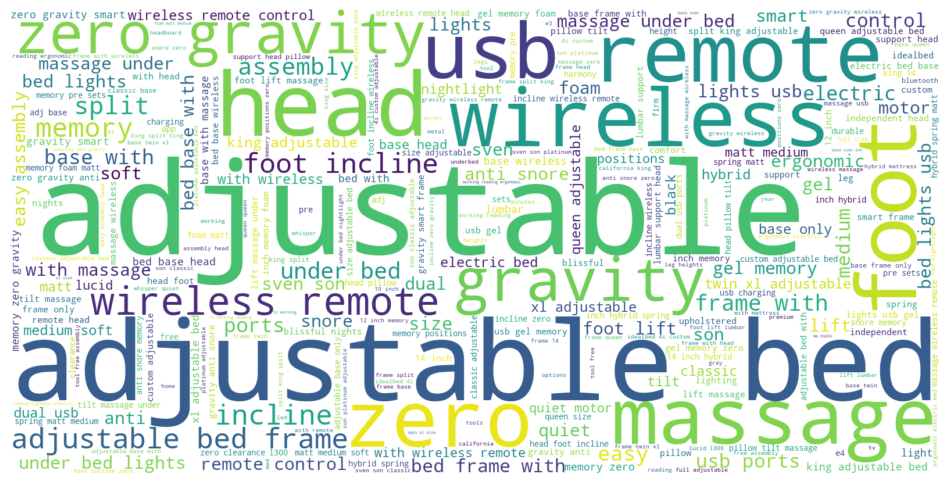

In [66]:

# ==== 사용자 정의 stopwords ====
custom_stopwords = {
    # 기본 제외 키워드
    "bed", "bed frame", "bed base", "base", "frame",
    "adjustable bed base", "adjustable base", "base frame", "bed base frame",
    "under", "only", "inch",
    # 사이즈 관련
    "king", "queen", "twin", "xl", "full", "split king", "twin xl",
    # 매트리스 관련
    "mattress", "memory foam", "foam mattress", "memory foam mattress"
}

# 기본 STOPWORDS + 사용자 정의
stopwords = STOPWORDS.union(custom_stopwords)

# ==== 필터링 함수 정의 ====
def is_valid_ngram(ngram: str) -> bool:
    # 1) stopwords 직접 제외
    if ngram in stopwords:
        return False
    # 2) 숫자만 있는 경우 제외 (예: "10", "14")
    if re.fullmatch(r"\d+", ngram):
        return False
    # 3) and가 포함된 2-gram/3-gram 제외
    if "and" in ngram.split() and len(ngram.split()) > 1:
        return False
    return True

# ==== DataFrame 필터링 ====
filtered_df = ngram_freq[ngram_freq['ngram'].apply(is_valid_ngram)].copy()

# ==== WordCloud 생성 ====
word_freq_dict = dict(zip(filtered_df['ngram'], filtered_df['count']))

wc = WordCloud(
    width=1600, height=800,
    background_color="white",
    colormap="viridis",
    stopwords=stopwords,
    max_words=300
).generate_from_frequencies(word_freq_dict)

# ==== 시각화 ====
plt.figure(figsize=(12,10))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [62]:
filtered_df.to_csv('adjustable_ngram_filtered_0829.csv')

In [110]:
word_freq_dict

{'adjustable': 171000,
 'adjustable bed': 128146,
 'head': 75488,
 'foot': 67088,
 'remote': 62918,
 'wireless': 60808,
 'zero': 59206,
 'massage': 58238,
 'usb': 56678,
 'gravity': 52072,
 'zero gravity': 52024,
 'wireless remote': 51524,
 'adjustable bed frame': 47050,
 'incline': 46078,
 'foot incline': 43388,
 'memory': 42086,
 'split': 36150,
 'assembly': 33228,
 'under bed': 29880,
 'frame with': 28052,
 'easy': 24994,
 'base with': 24186,
 'ports': 23634,
 'electric': 22708,
 'control': 21484,
 'medium': 21340,
 'usb ports': 20928,
 'bed frame with': 20282,
 'size': 19546,
 'ergonomic': 18080,
 'sven': 17742,
 'son': 17742,
 'anti': 17718,
 'remote control': 17566,
 'bed base with': 17520,
 'anti snore': 17364,
 'snore': 17364,
 'lift': 17236,
 'foot lift': 16900,
 'motor': 16406,
 'lights': 16372,
 'dual': 16342,
 'with massage': 16310,
 'massage under bed': 16256,
 'massage under': 16256,
 'under bed lights': 16054,
 'bed lights': 16054,
 'foam': 15680,
 'sven son': 15548,
 's

### Bed Totals 부분

In [29]:
df1 = df_beds_bedframes[df_beds_bedframes['WeekId'] >= 202501]

In [31]:
print(df1)

         RetailerId RetailerName RetailerSku  upc            ModelNumber  \
47290             1   Amazon.com  B0D3L2KW9D  NaN                10 Inch   
47291             1   Amazon.com  B0CSPCFGTN  NaN               SXLL5010   
47292             1   Amazon.com  B0D5HH3R3F  NaN            FU28-35F-12   
47293             1   Amazon.com  B0D5HH149V  NaN            FU28-35Q-12   
47294             1   Amazon.com  B0CMW32XHT  NaN                LTT5012   
...             ...          ...         ...  ...                    ...   
2656982           1   Amazon.com  B0CK1MB2MZ  NaN                 RIB002   
2656983           1   Amazon.com  B0CKRWRH26  NaN                  RX874   
2656984           1   Amazon.com  B0C6YDYZXZ  NaN                 10091F   
2656985           1   Amazon.com  B0CJXX2VN8  NaN  SET FLAT KING CARAMEL   
2656986           1   Amazon.com  B0CKWXKLMX  NaN   QX-FX-SUN-BFQUEEN-DG   

                                                     Title        Brand  \
47290    10 

In [41]:

# 1) 벡터라이저: 메모리 절약 옵션
vectorizer = CountVectorizer(
    ngram_range=(1, 3),
    lowercase=True,
    token_pattern=r"[a-z0-9]+",    # 간단 토큰화
    max_features=50000,            # 필요 시 조정
    min_df=2,                      # 2개 미만 문서에만 등장하는 n-gram 제거
    max_df=0.5,                    # 너무 흔한 n-gram 제거(문서 비율 50% 초과)
    dtype=np.int32                 # 기본 int64보다 절반 메모리
)

# 2) 희소행렬 생성 (title만 사용)
X = vectorizer.fit_transform(df1['Title'].fillna(''))

# 3) 희소합으로 빈도 계산 (밀집 변환 금지!)
# axis=0 로 각 컬럼(ngram) 합계, .A1으로 1D 배열
word_counts = np.asarray(X.sum(axis=0)).ravel()

# 4) DataFrame 정렬
ngram_freq = pd.DataFrame({
    "ngram": vectorizer.get_feature_names_out(),
    "count": word_counts
}).sort_values("count", ascending=False, kind="mergesort") \
  .reset_index(drop=True)

print(ngram_freq.head(50))

                   ngram   count
0           platform bed  232712
1                storage  211928
2                    and  194219
3                   easy  189229
4                   twin  188349
5                  metal  181601
6               assembly  181485
7          easy assembly  172601
8                  queen  171336
9            upholstered  168652
10               support  162931
11                  full  161041
12              bed with  148570
13                  wood  146091
14                 slats  135141
15    platform bed frame  128404
16                 noise  120404
17                  free  116876
18            noise free  110614
19                 black  108397
20                   for  107953
21              size bed  106443
22        size bed frame   98768
23                 heavy   97857
24                  king   97539
25                  duty   96551
26            heavy duty   96190
27                   led   91944
28             full size   90188
29        

## 5. 신제품 분석

In [71]:
df_adjustable = df[df['last_category']=='Adjustable Bases'].copy()

In [75]:
df1 = df_adjustable.copy()

In [77]:
print(df1)

              asin                                              title  \
1797    B074LGTDSH  S-Cape 2.0 Leggett and Platt Adjustable Bed Ba...   
1917    B0DGGN6THK  Adjustable Bed Frame Queen with 4-Level Height...   
1918    B0DGGP822P  Twin XL Adjustable Bed Frame, Adjustable Bed B...   
1991    B07FCW9T6H  Blissful Nights Split King e4 Adjustable Bed B...   
1992    B07FCW9T6H  Blissful Nights Split King e4 Adjustable Bed B...   
...            ...                                                ...   
272750  B08LX9FD8Q  Naomi Home Serenity Split King Adjustable Bed ...   
272751  B08LX9FD8Q  Naomi Home Serenity Split King Adjustable Bed ...   
272752  B08LX9FD8Q  Naomi Home Serenity Split King Adjustable Bed ...   
272753  B08LX9FD8Q  Naomi Home Serenity Split King Adjustable Bed ...   
272754  B08LX9FD8Q  Naomi Home Serenity Split King Adjustable Bed ...   

                                                 keywords            brand  \
1797    S-Cape,2.0,Leggett,and,Platt,Adjustab

In [96]:
# 1. datetime 변환
df1['first_available_utc'] = pd.to_datetime(df1['first_available_utc'], errors='coerce')

# 2. year 생성 (NaN 그대로 두기 → int 변환은 나중에)
df1['year'] = df1['first_available_utc'].dt.year

# 3. 2021년 이상만 필터링 & NaN 제거 → int 변환
unique_asin_per_year = (
    df1[df1['year'].notna() & (df1['year'] >= 2021)]
      .assign(year=lambda x: x['year'].astype(int))
      .groupby('year')['asin']
      .nunique()
      .reset_index(name='unique_asin_count')
)

print(unique_asin_per_year)


   year  unique_asin_count
0  2021                115
1  2022                144
2  2023                261
3  2024                367
4  2025                611


In [108]:
brand_asin_count = (
    df1[df1['year'].isin([2024, 2025])]
      .groupby('brand')['asin']
      .nunique()
      .sort_values(ascending=False)   # 여기서 정렬
      .reset_index(name='unique_asin_count')  # 여기서 한 번만 reset_index
)

print(brand_asin_count.head(20))

                   brand  unique_asin_count
0                Udorich                 49
1                Vipbear                 47
2              FLEXISPOT                 42
3                Marsail                 41
4                IJOWEEN                 38
5             Benicabaly                 33
6                Nirvaer                 30
7                  Seeye                 29
8                   LJLB                 27
9                EGOHOME                 27
10               Renanim                 25
11            SHARK SHIP                 25
12                ESHINE                 25
13                YLIEHS                 19
14               Dyonery                 19
15               THEMEPT                 18
16  AMADA HOMEFURNISHING                 17
17              arsehhwe                 17
18               HXUHUWS                 16
19                Donext                 16


In [40]:
#target_cate = [None, 'Adjustable Bases', 'Beds', 'Bed Frames']
target_cate = [None, 'Adjustable Bases']

df1 = df[df['last_category'].isin(target_cate)].copy()

In [42]:
df1['asin'].nunique()

4306

In [44]:
# asin, title, keywords 기준으로 group by + row 개수
grouped = (
    #df1.groupby(['asin', 'title', 'keywords'])
    df1.groupby(['asin'])
       .size()
       .reset_index(name='count')
       .sort_values(by='count', ascending=False)   # 큰 순 정렬
)

print(grouped)  # 상위 20개 확인

            asin  count
232   B074R8QKJ1    345
410   B07KH29X8V    345
231   B074QWYM22    343
442   B07LCWL94B    330
354   B07FJM65KK    327
...          ...    ...
1282  B08VH6TRFC      1
116   B01MYBUE9M      1
1941  B09QL9V5HP      1
1943  B09QMHGBZR      1
4305  B0FNM8V94B      1

[4306 rows x 2 columns]


In [46]:
df_asin = (
    df1.groupby('asin')
       .agg(
           count=('asin','size'),
           sales=('RetailSales','sum'),
           title=('title', lambda x: list(set(x.dropna()))),
           keywords=('keywords', lambda x: list(set(x.dropna()))),
           last_category=('last_category', lambda x: list(set(x.dropna())))
       )
       .reset_index()
       .sort_values(by='sales', ascending=False)
)

print(df_asin)

            asin  count        sales  \
497   B07MHWDTX9    321  28837292.17   
442   B07LCWL94B    330  19187592.41   
231   B074QWYM22    343  18926667.90   
232   B074R8QKJ1    345  15509958.04   
1020  B08BJFJ74R    246  15006947.70   
...          ...    ...          ...   
3788  B0F23K6DZ8      1         0.00   
3789  B0F29F28WM      1         0.00   
1185  B08NVPFHZ9      1         0.00   
3805  B0F3D9DNJG      1         0.00   
4305  B0FNM8V94B      1         0.00   

                                                  title  \
497   [Sven & Son Classic Adjustable Bed Base, Head ...   
442   [Sven & Son Platinum Adjustable Bed Base Frame...   
231   [LUCID L300 Adjustable Bed Frame - Head and Fo...   
232   [LUCID L300 Adjustable Bed Frame - Head and Fo...   
1020  [Best Choice Products Ergonomic Queen Size Adj...   
...                                                 ...   
3788  [Queen Adjustable Bed Frame, Electric Bed Fram...   
3789  [Split King Adjustable Bed Base Frame, El

In [68]:
#df_asin.to_csv('df_asin_0817.csv')


In [76]:
# last_category가 빈 리스트([])인 경우
df_asin_null = df_asin[df_asin['last_category'].apply(lambda x: isinstance(x, list) and len(x) == 0)].copy()

print(df_asin_null)

            asin  count       sales  \
764   B07YVCG56Y     78  2317969.33   
295   B07983G4D4    175  2157719.81   
617   B07VLSR6XM     97  2140243.61   
1645  B09B34C48F     91  1353479.00   
625   B07VSXY7NZ     93  1195460.84   
...          ...    ...         ...   
1182  B08NVM1J46      1        0.00   
1116  B08L833SDK     13        0.00   
1100  B08KLDKWN7      9        0.00   
1186  B08NVPJVZW      1        0.00   
1185  B08NVPFHZ9      1        0.00   

                                                  title keywords last_category  
764   [Adjustable Bed Base Frame Smart Electric Beds...       []            []  
295   [DynastyMattress DM9000s Split King Adjustable...       []            []  
617   [Amolife Upholstered Queen Bed Frame/Deluxe So...       []            []  
1645  [Einfach King Size Platform Bed Frame with Adj...       []            []  
625   [Amolife Upholstered Platform Bed Full/Deluxe ...       []            []  
...                                          

In [98]:
# 1. Title + Keyword 결합 후 소문자로 변환
df_asin_null['text'] = (
    df_asin_null['title'].fillna('').astype(str) + ' ' + 
    df_asin_null['keywords'].fillna('').astype(str)
).str.lower()

# 2. NaN → 빈 문자열 보정
df_asin_null['text'] = df_asin_null['text'].fillna('')

# 3. 1-gram 토큰화 (빈 문자열도 포함되도록)
vectorizer = CountVectorizer(ngram_range=(1,1))
X = vectorizer.fit_transform(df_asin_null['text'].tolist())   # list 변환 후 fit_transform

tokens = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df_asin_null.index   # ✅ df_asin_null과 동일하게 맞추기
)

# 4. case별 조건 정의 (단어가 없으면 0 처리)
case1 = (tokens.get('adjustable', 0) > 0) & (tokens.get('headboard', 0) > 0)
case2 = (tokens.get('adjustable', 0) > 0) & (tokens.get('height', 0) > 0)
case3 = (tokens.get('adjustable', 0) > 0) & (tokens.get('legs', 0) > 0)
case4 = (tokens.get('compatible', 0) > 0) & (tokens.get('with', 0) > 0) & (tokens.get('adjustable', 0) > 0)
case5 = (tokens.get('anti', 0) > 0) & (tokens.get('shake', 0) > 0) & (tokens.get('tool', 0) > 0)
case6 = (tokens.get('memory', 0) > 0) & (tokens.get('foam', 0) > 0) 

# 5. 제외 조건 적용
exclude_mask = case1 | case2 | case3 | case4 | case5 | case6 
df_filtered = df_asin_null.loc[~exclude_mask].copy()

print(df_filtered)

            asin  count       sales  \
764   B07YVCG56Y     78  2317969.33   
295   B07983G4D4    175  2157719.81   
765   B07YVCXBRJ     76   716198.05   
1403  B091TV8BB6     46   611628.70   
892   B084V3XMM7     84   521652.00   
...          ...    ...         ...   
1603  B098K5HN8N      1        0.00   
1602  B098K5BCBS      1        0.00   
1690  B09CDF3B9D      1        0.00   
1652  B09B69HH3N      3        0.00   
1100  B08KLDKWN7      9        0.00   

                                                  title keywords  \
764   [Adjustable Bed Base Frame Smart Electric Beds...       []   
295   [DynastyMattress DM9000s Split King Adjustable...       []   
765   [Adjustable Bed Base Frame Smart Electric Beds...       []   
1403  [Allewie Adjustable Bed Base Frame / Queen Siz...       []   
892   [iDealBed 5i Custom Adjustable Bed Base, Wall ...       []   
...                                                 ...      ...   
1603  [Twin XL Upgraded Adjustable Bed Base Frame, W...

In [96]:
df_filtered.to_csv('df_filtered_0817.csv')

In [61]:
#

In [63]:
# 1. Title + Keyword 결합 후 소문자 변환
df1['text'] = (df1['title'].fillna('') + ' ' + df1['keywords'].fillna('')).str.lower()

# 2. 일반화된 adjustable 패턴
adjustable_pattern = re.compile(
    r'\badjustable\b.*?\b(bed|beds?|bases?|base|frame|frames?)\b'
)

# 3. 최종 분류 (조건: adjustable은 포함, compatible with adjustable은 제외)
df1['is_adjustable'] = df1['text'].str.contains(adjustable_pattern)

# 5. Adjustable 제품만 추출
df_adjustable = df1[df1['is_adjustable']].copy()

print(df_adjustable[['title', 'keywords', 'is_adjustable']].head())

C:\Users\최태욱\AppData\Local\Temp\ipykernel_3380\2533392647.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df1['is_adjustable'] = df1['text'].str.contains(adjustable_pattern)


                                                title keywords  is_adjustable
3   Urest King Bed Frame Deluxe Solid Morden Platf...     None           True
6   Einfach Motorized Adjustable Bed Base/Full Siz...     None           True
7   Blissful Nights e3 Cal King Split Adjustable B...     None           True
8   Allewie Queen Size Bed Frame with Curved Adjus...     None           True
11  Kealive Deluxe Upholstered Sleigh Bed Frame wi...     None           True


In [71]:
df_adjustable['last_category_filled'] = df_adjustable['last_category'].fillna('NULL')
df_adjustable.groupby('last_category')['asin'].nunique()

last_category
Adjustable Bases    2189
Bed Frames          5872
Beds                 719
Name: asin, dtype: int64

In [47]:
# 1. Title + Keyword 결합 후 소문자로 변환
#df2['text'] = (df2['title'].fillna('') + ' ' + df2['keywords'].fillna('')).str.lower()

# 2. NaN → 빈 문자열 보정
df2['text'] = df2['text'].fillna('')

# 3. 1-gram 토큰화 (빈 문자열도 포함되도록)
vectorizer = CountVectorizer(ngram_range=(1,1))
X = vectorizer.fit_transform(df2['text'].tolist())   # ✅ list 변환 후 fit_transform
tokens = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df2.index[:X.shape[0]]   # ✅ row 수 강제로 맞추기
)

# 4. case별 조건 정의 (단어가 없으면 0 처리)
case1 = (tokens.get('adjustable', 0) > 0) & (tokens.get('headboard', 0) > 0)
case2 = (tokens.get('adjustable', 0) > 0) & (tokens.get('height', 0) > 0)
case3 = (tokens.get('adjustable', 0) > 0) & (tokens.get('legs', 0) > 0)
case4 = (tokens.get('compatible', 0) > 0) & (tokens.get('with', 0) > 0) & (tokens.get('adjustable', 0) > 0)

# 5. 제외 조건 적용
exclude_mask = case1 | case2 | case3 | case4
df_filtered = df2.loc[~exclude_mask].copy()

In [54]:
df_filtered['last_category_filled'] = df_filtered['last_category'].fillna('NULL')
df_filtered.groupby('last_category_filled')['asin'].nunique()

last_category_filled
Adjustable Bases    1904
Bed Frames           567
Beds                 300
NULL                 973
Name: asin, dtype: int64

In [56]:
df_filtered.to_csv('temp111.csv')

In [41]:
# WeekId에서 연도 추출
df['year'] = df['WeekId'].astype(str).str[:4].astype(int)

# 년도별 매출 및  SKU 개수 합계
sales_by_year = (
    df.groupby('year').agg(
        size=('RetailSales','sum'), 
        suk=('RetailerSku','nunique')
    )
    .reset_index()
)
# 보기 좋게 포맷 (Million 단위 표시 예시)
sales_by_year['RetailSales_Million'] = sales_by_year['size'] / 1_000_000

print(sales_by_year)

   year          size   suk  RetailSales_Million
0  2019  6.694799e+07  1009            66.947988
1  2020  8.686491e+07  1282            86.864913
2  2021  1.184291e+08  1909           118.429054
3  2022  1.926677e+08  2600           192.667716
4  2023  2.112892e+08  3900           211.289167
5  2024  2.291538e+08  5647           229.153768
6  2025  1.307081e+08  4257           130.708077


In [25]:
df['WeekId'].min()

201901

In [43]:
from sklearn.feature_extraction.text import CountVectorizer

In [45]:

# 예시: Title 컬럼 사용
titles = df['Title'].dropna().astype(str).tolist()

# 1~3 gram 추출
vectorizer = CountVectorizer(ngram_range=(1,3), stop_words='english')
X = vectorizer.fit_transform(titles)

# ngram 단어/구 조합과 빈도 매핑
ngram_counts = X.toarray().sum(axis=0)
ngram_freq = pd.DataFrame({
    'ngram': vectorizer.get_feature_names_out(),
    'count': ngram_counts
})

# 빈도수 내림차순 정렬
ngram_freq = ngram_freq.sort_values(by='count', ascending=False).reset_index(drop=True)

print(ngram_freq.head(30))  # 상위 30개 출력

                   ngram   count
0                    bed  415214
1             adjustable  281825
2                  frame  269199
3              bed frame  239892
4              headboard  170252
5            upholstered  126142
6                 spring  125295
7                    box  124840
8               platform  122300
9             box spring  122242
10                  size  106145
11                needed  104261
12               support  103523
13         spring needed  103329
14     box spring needed  103298
15                 queen  102996
16          platform bed   96897
17  adjustable headboard   89475
18              assembly   82365
19        adjustable bed   79981
20                  easy   78228
21                  king   71281
22         easy assembly   69542
23                  base   66820
24                 slats   66455
25                  wood   65288
26              mattress   63564
27                  twin   59925
28      frame adjustable   59428
29  bed fr

In [47]:
ngram_freq.to_csv('adjustable_title_words.csv')

##### Clustering 모델 적용하기

In [49]:
import re
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [53]:
# =========================
# 0) 공통 유틸
# =========================
def normalize_keywords_list(x):
    """keywords_list가 문자열 형태의 리스트여도 안전하게 리스트로 복구"""
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            val = literal_eval(x)
            if isinstance(val, list):
                return val
        except Exception:
            pass
        return [t.strip() for t in x.split(",") if t.strip()]
    return []

def build_text(row):
    title = (row.get("title") or "").lower()
    desc = (row.get("description") or "").lower()
    kw_list = normalize_keywords_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""

    text = " ".join([title, kw, desc])
    text = re.sub(r"[^a-z0-9\s\-\+']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def subset_by_category(df, main_cat="Beds"):
    return df.loc[df["category5"] == main_cat].copy()

def top_terms_per_cluster(kmeans_model, vectorizer, topn=15):
    centroids = kmeans_model.cluster_centers_
    terms = np.array(vectorizer.get_feature_names_out())
    top_terms = {}
    for cid in range(centroids.shape[0]):
        idx = centroids[cid].argsort()[::-1][:topn]
        top_terms[cid] = terms[idx].tolist()
    return top_terms

# 클러스터명 규칙 (이전 코드와 동일/확장 가능)
NAME_RULES = [
    (["bunk", "ladder"], "Bunk Beds"),
    (["loft", "desk"], "Loft Beds"),
    (["daybed", "day bed"], "Daybeds"),
    (["canopy"], "Canopy Beds"),
    (["platform", "slat"], "Platform Beds"),
    (["storage", "drawer", "trundle"], "Storage Beds"),
    (["upholstered", "velvet", "fabric", "linen"], "Upholstered Beds"),
    (["metal", "steel", "iron"], "Metal Beds"),
    (["wood", "wooden", "pine", "oak", "acacia", "walnut", "solid"], "Wood Beds"),
    (["kids", "toddler"], "Kids Beds"),
    (["murphy", "cabinet"], "Other: murphy, cabinet, murphy bed"),
]

def name_cluster(term_list):
    joined = " ".join(term_list)
    for keys, label in NAME_RULES:
        if any(k in joined for k in keys):
            return label
    return "Other: " + ", ".join(term_list[:3])

# =========================
# 1) 카테고리별 클러스터링 함수
# =========================
def cluster_one_category(df_cat, candidate_k=(8,10,12,15,18), tfidf=None):
    df_cat = df_cat[df_cat["title"].notna()].copy()
    df_cat["text"] = df_cat.apply(build_text, axis=1)

    # 벡터화
    if tfidf is None:
        tfidf = TfidfVectorizer(
            max_features=30000,
            ngram_range=(1,2),
            min_df=5,
            stop_words="english",
        )
        X = tfidf.fit_transform(df_cat["text"])
        fitted_vectorizer = tfidf
    else:
        X = tfidf.transform(df_cat["text"])
        fitted_vectorizer = tfidf

    # k 선택(빠르게 하고 싶으면 고정 k 사용)
    sil_scores = {}
    for k in candidate_k:
        km_tmp = KMeans(n_clusters=k, n_init="auto", random_state=42)
        labels_tmp = km_tmp.fit_predict(X)
        if X.shape[0] > 20000:
            idx = np.random.choice(X.shape[0], min(20000, X.shape[0]), replace=False)
            score = silhouette_score(X[idx], labels_tmp[idx])
        else:
            score = silhouette_score(X, labels_tmp)
        sil_scores[k] = score
    best_k = max(sil_scores, key=sil_scores.get)

    # 최종 적합
    kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=42)
    df_cat["cluster_id"] = kmeans.fit_predict(X)

    # 클러스터 대표 키워드 → 이름
    cluster_terms = top_terms_per_cluster(kmeans, fitted_vectorizer, topn=20)
    cluster_name_map = {cid: name_cluster(cluster_terms[cid]) for cid in cluster_terms}
    df_cat["cluster_name"] = df_cat["cluster_id"].map(cluster_name_map)

    return df_cat, fitted_vectorizer, kmeans, cluster_terms, sil_scores

# =========================
# 2) Platform Beds 내부 세분화
# =========================
def classify_platform_bed_row(row):
    """
    Platform Beds 내부를 Metal / Wood / Upholstered / Storage / Other로 세분화.
    title, keywords_list, specifications_flat(재질/수납 단서) 활용.
    """
    title = (row.get("title") or "").lower()
    kw_list = normalize_keywords_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""
    specs = (row.get("specifications_flat") or "").lower()

    text_all = " ".join([title, kw, specs])

    # Storage 먼저(가장 명확한 의도)
    if any(w in text_all for w in ["storage", "drawer", "drawers", "trundle", "lift up", "gas lift", "underbed", "under bed"]):
        return "Storage Platform Beds"

    # 재질 기반
    if any(w in text_all for w in ["metal", "steel", "iron"]):
        return "Metal Platform Beds"
    if any(w in text_all for w in ["upholstered", "velvet", "linen", "fabric", "faux leather", "leather"]):
        return "Upholstered Platform Beds"
    if any(w in text_all for w in ["wood", "wooden", "pine", "oak", "acacia", "walnut", "mdf", "plywood", "solid wood", "solid"]):
        return "Wood Platform Beds"

    return "Other Platform Beds"

def refine_platform_beds(df_all):
    """
    cluster_name이 'Platform Beds' 인 행들만 세분화.
    세분화 라벨은 최종 SubCategory로 사용.
    기타 클러스터는 기존 cluster_name 사용.
    """
    df_all = df_all.copy()
    is_platform = df_all["cluster_name"].eq("Platform Beds")

    df_all.loc[is_platform, "SubCategory"] = df_all.loc[is_platform].apply(classify_platform_bed_row, axis=1)
    df_all.loc[~is_platform, "SubCategory"] = df_all.loc[~is_platform, "cluster_name"]
    return df_all

# =========================
# 3) 실행 (Beds / Bed Frames → 병합 → 세분화)
# =========================
# 예: df 원본에 category5, title, keywords_list, description, specifications_flat 등이 있다고 가정
# df = ...

# Beds
df_beds = subset_by_category(df, "Beds")
df_beds, vec_beds, km_beds, terms_beds, sil_beds = cluster_one_category(df_beds)

# Bed Frames
df_frames = subset_by_category(df, "Bed Frames")
# (벡터라이저를 공유하지 않고 각 도메인 단독 피쳐로 학습하는 쪽이 일반적으로 성능/해석이 낫습니다)
df_frames, vec_frames, km_frames, terms_frames, sil_frames = cluster_one_category(df_frames)

# 병합
df_clustered = pd.concat([df_beds, df_frames], ignore_index=True)

# Platform Beds 내부 세분화 적용
df_final = refine_platform_beds(df_clustered)

# =========================
# 4) 결과 확인
# =========================
# (1) 전체 요약: SubCategory 별 개수
summary = (
    df_final.groupby(["category5", "SubCategory"])
            .agg(n_items=("asin", "count"))
            .sort_values("n_items", ascending=False)
)
print(summary.head(30))

# (2) Platform Beds 내부 세분화 결과
platform_summary = (
    df_final.loc[df_final["SubCategory"].str.contains("Platform Beds", na=False)]
             .groupby("SubCategory")
             .size()
             .sort_values(ascending=False)
)
print("\n[Platform Beds breakdown]")
print(platform_summary)

# 필요시 저장
# df_final.to_parquet("subcat_with_platform_refined.parquet", index=False)

                                               n_items
category5  SubCategory                                
Bed Frames Storage Platform Beds                 15086
           Upholstered Platform Beds              8246
           Metal Platform Beds                    7779
Beds       Daybeds                                6887
           Bunk Beds                              6316
Bed Frames Storage Beds                           4989
Beds       Storage Platform Beds                  3247
Bed Frames Daybeds                                2934
           Wood Platform Beds                     2714
Beds       Upholstered Platform Beds              2708
Bed Frames Other: murphy, cabinet, murphy bed     1695
           Bunk Beds                              1494
Beds       Other: murphy, cabinet, murphy bed     1364
           Wood Platform Beds                     1347
           Metal Platform Beds                    1004
Bed Frames Kids Beds                               865
          

In [55]:

# =========================
# 0) 공통 유틸
# =========================
def normalize_keywords_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            val = literal_eval(x)
            if isinstance(val, list):
                return val
        except Exception:
            pass
        return [t.strip() for t in x.split(",") if t.strip()]
    return []

def build_text(row):
    title = (row.get("title") or "").lower()
    desc = (row.get("description") or "").lower()
    kw_list = normalize_keywords_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""
    text = " ".join([title, kw, desc])
    text = re.sub(r"[^a-z0-9\s\-\+']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def subset_by_category(df, main_cat="Beds"):
    return df.loc[df["category5"] == main_cat].copy()

def top_terms_per_cluster(kmeans_model, vectorizer, topn=15):
    centroids = kmeans_model.cluster_centers_
    terms = np.array(vectorizer.get_feature_names_out())
    top_terms = {}
    for cid in range(centroids.shape[0]):
        idx = centroids[cid].argsort()[::-1][:topn]
        top_terms[cid] = terms[idx].tolist()
    return top_terms

# 클러스터명 규칙
NAME_RULES = [
    (["bunk", "ladder"], "Bunk Beds"),
    (["loft", "desk"], "Loft Beds"),
    (["daybed", "day bed"], "Daybeds"),
    (["canopy"], "Canopy Beds"),
    (["platform", "slat"], "Platform Beds"),
    (["storage", "drawer", "trundle"], "Storage Beds"),
    (["upholstered", "velvet", "fabric", "linen"], "Upholstered Beds"),
    (["metal", "steel", "iron"], "Metal Beds"),
    (["wood", "wooden", "pine", "oak", "acacia", "walnut", "mdf", "plywood", "solid"], "Wood Beds"),
    (["kids", "toddler"], "Kids Beds"),
    (["murphy", "cabinet"], "Other: murphy, cabinet, murphy bed"),
]

def name_cluster(term_list):
    joined = " ".join(term_list)
    for keys, label in NAME_RULES:
        if any(k in joined for k in keys):
            return label
    return "Other: " + ", ".join(term_list[:3])

# =========================
# 1) 카테고리별 클러스터링
# =========================
def cluster_one_category(df_cat, candidate_k=(8,10,12,15,18), tfidf=None):
    df_cat = df_cat[df_cat["title"].notna()].copy()
    df_cat["text"] = df_cat.apply(build_text, axis=1)

    if tfidf is None:
        tfidf = TfidfVectorizer(
            max_features=30000,
            ngram_range=(1,2),
            min_df=5,
            stop_words="english",
        )
        X = tfidf.fit_transform(df_cat["text"])
        fitted_vectorizer = tfidf
    else:
        X = tfidf.transform(df_cat["text"])
        fitted_vectorizer = tfidf

    # k 선택(샘플링 실루엣)
    sil_scores = {}
    for k in candidate_k:
        km_tmp = KMeans(n_clusters=k, n_init="auto", random_state=42)
        labels_tmp = km_tmp.fit_predict(X)
        if X.shape[0] > 20000:
            idx = np.random.choice(X.shape[0], min(20000, X.shape[0]), replace=False)
            score = silhouette_score(X[idx], labels_tmp[idx])
        else:
            score = silhouette_score(X, labels_tmp)
        sil_scores[k] = score
    best_k = max(sil_scores, key=sil_scores.get)

    kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=42)
    df_cat["cluster_id"] = kmeans.fit_predict(X)

    cluster_terms = top_terms_per_cluster(kmeans, fitted_vectorizer, topn=20)
    cluster_name_map = {cid: name_cluster(cluster_terms[cid]) for cid in cluster_terms}
    df_cat["cluster_name"] = df_cat["cluster_id"].map(cluster_name_map)

    return df_cat, fitted_vectorizer, kmeans, cluster_terms, sil_scores

# =========================
# 2) Platform Beds: 재질 먼저 분류 + Storage는 속성 태깅
# =========================
def detect_storage(row):
    title = (row.get("title") or "").lower()
    specs = (row.get("specifications_flat") or "").lower()
    kw_list = normalize_keywords_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""
    text = " ".join([title, kw, specs])
    storage_terms = ["storage", "drawer", "drawers", "trundle", "underbed", "under bed", "lift up", "gas lift", "lift-up"]
    return any(w in text for w in storage_terms)

def classify_platform_material(row):
    # 재질 우선(단일 레이블)
    title = (row.get("title") or "").lower()
    specs = (row.get("specifications_flat") or "").lower()
    kw_list = normalize_keywords_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""
    text = " ".join([title, kw, specs])

    if any(w in text for w in ["upholstered", "velvet", "linen", "fabric", "faux leather", "leather"]):
        return "Upholstered Platform Beds"
    if any(w in text for w in ["metal", "steel", "iron"]):
        return "Metal Platform Beds"
    if any(w in text for w in ["wood", "wooden", "pine", "oak", "acacia", "walnut", "mdf", "plywood", "solid wood", "solid"]):
        return "Wood Platform Beds"
    return "Other Platform Beds"

def refine_platform_beds_material_first(df_all):
    df_all = df_all.copy()
    is_platform = df_all["cluster_name"].eq("Platform Beds")

    # 재질 기반 단일 레이블
    df_all.loc[is_platform, "SubCategory"] = df_all.loc[is_platform].apply(classify_platform_material, axis=1)
    # Storage 속성 태그(Boolean)
    df_all.loc[is_platform, "has_storage"] = df_all.loc[is_platform].apply(detect_storage, axis=1)

    # Platform이 아닌 경우는 원래 클러스터명 사용, has_storage는 False로
    df_all.loc[~is_platform, "SubCategory"] = df_all.loc[~is_platform, "cluster_name"]
    df_all.loc[~is_platform, "has_storage"] = False

    # (선택) 속성을 문자열로도 보유
    df_all["Attributes"] = np.where(df_all["has_storage"], "Storage", "")
    return df_all

# =========================
# 3) 실행 (Beds / Bed Frames → 병합 → 재질 우선 + Storage 태깅)
# =========================
# df = ...  # 원본 DataFrame (category5, title, keywords_list, description, specifications_flat 등 포함)

# Beds
df_beds = subset_by_category(df, "Beds")
df_beds, vec_beds, km_beds, terms_beds, sil_beds = cluster_one_category(df_beds)

# Bed Frames
df_frames = subset_by_category(df, "Bed Frames")
df_frames, vec_frames, km_frames, terms_frames, sil_frames = cluster_one_category(df_frames)

# 병합
df_clustered = pd.concat([df_beds, df_frames], ignore_index=True)

# Platform Beds: 재질 기반 SubCategory + Storage 태깅
df_final = refine_platform_beds_material_first(df_clustered)

# =========================
# 4) 결과 확인
# =========================
# (1) 전체 요약: SubCategory x has_storage
summary = (
    df_final.groupby(["category5", "SubCategory", "has_storage"])
            .agg(n_items=("asin", "count"))
            .sort_values("n_items", ascending=False)
)
print(summary.head(30))

# (2) Platform Beds만 재질-속성 분해 요약
plat = df_final[df_final["SubCategory"].str.contains("Platform Beds", na=False)]
plat_summary = (
    plat.groupby(["SubCategory", "has_storage"])
        .size()
        .unstack("has_storage", fill_value=0)
        .rename(columns={False:"no_storage", True:"has_storage"})
        .sort_values("has_storage", ascending=False)
)
print("\n[Platform Beds breakdown by material + storage]")
print(plat_summary)


                                                           n_items
category5  SubCategory                        has_storage         
Bed Frames Upholstered Platform Beds          False          11122
                                              True            7832
Beds       Daybeds                            False           6887
           Bunk Beds                          False           6316
Bed Frames Storage Beds                       False           4989
           Metal Platform Beds                False           4903
                                              True            3922
Beds       Upholstered Platform Beds          False           3219
Bed Frames Daybeds                            False           2934
           Wood Platform Beds                 True            2904
                                              False           2714
           Other: murphy, cabinet, murphy bed False           1695
           Bunk Beds                          False           

In [58]:
summary.to_csv('summary_0819.csv')

In [60]:

# =========================
# 0) 공통 유틸
# =========================
def normalize_keywords_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            val = literal_eval(x)
            if isinstance(val, list):
                return val
        except Exception:
            pass
        return [t.strip() for t in x.split(",") if t.strip()]
    return []

def build_text(row):
    title = (row.get("title") or "").lower()
    desc = (row.get("description") or "").lower()
    kw_list = normalize_keywords_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""
    text = " ".join([title, kw, desc])
    text = re.sub(r"[^a-z0-9\s\-\+']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def text_all_fields(row):
    title = (row.get("title") or "").lower()
    specs = (row.get("specifications_flat") or "").lower()
    kw_list = normalize_keywords_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""
    return " ".join([title, kw, specs])

def subset_by_category(df, main_cat="Beds"):
    return df.loc[df["category5"] == main_cat].copy()

def top_terms_per_cluster(kmeans_model, vectorizer, topn=15):
    centroids = kmeans_model.cluster_centers_
    terms = np.array(vectorizer.get_feature_names_out())
    top_terms = {}
    for cid in range(centroids.shape[0]):
        idx = centroids[cid].argsort()[::-1][:topn]
        top_terms[cid] = terms[idx].tolist()
    return top_terms

# =========================
# 1) 클러스터명 규칙 (초기 네이밍용)
#   - Adjustable/Storage 신호를 넣어 초기에 어느정도 분리되도록 보강
# =========================
NAME_RULES = [
    # Adjustable 키워드 (초기 클러스터 이름에서도 어느정도 반영)
    (["adjustable base", "adjustable bed", "adjustable frame", "zero gravity", "massage"], "Adjustable Beds"),
    (["bunk", "ladder"], "Bunk Beds"),
    (["loft", "desk"], "Loft Beds"),
    (["daybed", "day bed"], "Daybeds"),
    (["canopy"], "Canopy Beds"),
    # Platform의 일반 신호
    (["platform", "slat"], "Platform Beds"),
    # Storage 독립 신호 (platform 유무와 무관)
    (["storage", "drawer", "drawers", "trundle", "underbed", "under bed", "lift up", "lift-up", "hydraulic", "ottoman"], "Storage Beds"),
    # 재질 일반 신호
    (["upholstered", "velvet", "fabric", "linen"], "Upholstered Beds"),
    (["metal", "steel", "iron"], "Metal Beds"),
    (["wood", "wooden", "pine", "oak", "acacia", "walnut", "mdf", "plywood", "solid"], "Wood Beds"),
    (["kids", "toddler"], "Kids Beds"),
    (["murphy", "cabinet"], "Other: murphy, cabinet, murphy bed"),
]

def name_cluster(term_list):
    joined = " ".join(term_list)
    for keys, label in NAME_RULES:
        if any(k in joined for k in keys):
            return label
    return "Other: " + ", ".join(term_list[:3])

# =========================
# 2) 카테고리별 클러스터링
# =========================
def cluster_one_category(df_cat, candidate_k=(8,10,12,15,18), tfidf=None):
    df_cat = df_cat[df_cat["title"].notna()].copy()
    df_cat["text"] = df_cat.apply(build_text, axis=1)

    if tfidf is None:
        tfidf = TfidfVectorizer(
            max_features=30000,
            ngram_range=(1,2),
            min_df=5,
            stop_words="english",
        )
        X = tfidf.fit_transform(df_cat["text"])
        fitted_vectorizer = tfidf
    else:
        X = tfidf.transform(df_cat["text"])
        fitted_vectorizer = tfidf

    # k 선택(샘플링 실루엣)
    sil_scores = {}
    for k in candidate_k:
        km_tmp = KMeans(n_clusters=k, n_init="auto", random_state=42)
        labels_tmp = km_tmp.fit_predict(X)
        if X.shape[0] > 20000:
            idx = np.random.choice(X.shape[0], min(20000, X.shape[0]), replace=False)
            score = silhouette_score(X[idx], labels_tmp[idx])
        else:
            score = silhouette_score(X, labels_tmp)
        sil_scores[k] = score
    best_k = max(sil_scores, key=sil_scores.get)

    # 최종 적합
    kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=42)
    df_cat["cluster_id"] = kmeans.fit_predict(X)

    # 클러스터 대표 키워드 → 이름
    cluster_terms = top_terms_per_cluster(kmeans, fitted_vectorizer, topn=20)
    cluster_name_map = {cid: name_cluster(cluster_terms[cid]) for cid in cluster_terms}
    df_cat["cluster_name"] = df_cat["cluster_id"].map(cluster_name_map)

    return df_cat, fitted_vectorizer, kmeans, cluster_terms, sil_scores

# =========================
# 3) 우선순위 규칙 기반 최종 SubCategory 부여
#    - 1) Adjustable → Adjustable Beds
#    - 2) Storage → Storage Beds
#    - 3) Platform Beds면 재질(Material) 기준 세분화
#    - 4) 그 외는 cluster_name 사용
# =========================
ADJ_STRICT_TOKENS_ANY = [
    "zero gravity", "massage", "split king", "split-king", "split california king",
    "anti-snore", "anti snore", "lumbar", "remote", "wireless", "app control",
    "usb", "head incline", "foot incline", "motor", "motorized", "electric"
]
def detect_adjustable(text):
    text = text.lower()
    # 강한 패턴
    strong = any(p in text for p in ["adjustable base", "adjustable bed", "adjustable frame"])
    if strong:
        return True
    # 약한 패턴: 'adjustable' + (기능 키워드 중 하나)
    return ("adjustable" in text) and any(p in text for p in ADJ_STRICT_TOKENS_ANY)

STORAGE_TOKENS = [
    "storage", "drawer", "drawers", "trundle", "underbed", "under bed",
    "lift up", "lift-up", "gas lift", "hydraulic", "ottoman", "bookcase headboard"
]
def detect_storage(text):
    text = text.lower()
    return any(p in text for p in STORAGE_TOKENS)

def classify_platform_material(row):
    t = text_all_fields(row)
    if any(w in t for w in ["upholstered", "velvet", "linen", "fabric", "faux leather", "leather"]):
        return "Upholstered Platform Beds"
    if any(w in t for w in ["metal", "steel", "iron"]):
        return "Metal Platform Beds"
    if any(w in t for w in ["wood", "wooden", "pine", "oak", "acacia", "walnut", "mdf", "plywood", "solid wood", "solid"]):
        return "Wood Platform Beds"
    return "Other Platform Beds"

def apply_refinement_rules(df_all):
    df_all = df_all.copy()

    # 행 단위 규칙 적용
    def decide_subcat(row):
        txt = text_all_fields(row)

        # 1) Adjustable 우선
        if detect_adjustable(txt):
            return "Adjustable Beds"

        # 2) Storage 독립
        if detect_storage(txt):
            return "Storage Beds"

        # 3) Platform 재질 세분화
        if row.get("cluster_name") == "Platform Beds":
            return classify_platform_material(row)

        # 4) 기본: 클러스터명
        return row.get("cluster_name")

    df_all["SubCategory"] = df_all.apply(decide_subcat, axis=1)
    return df_all

# =========================
# 4) 실행 (Beds / Bed Frames → 병합 → 규칙 적용)
# =========================
# df = ...  # 원본 DataFrame (category5, title, keywords_list, description, specifications_flat 등 포함)

# Beds
df_beds = subset_by_category(df, "Beds")
df_beds, vec_beds, km_beds, terms_beds, sil_beds = cluster_one_category(df_beds)

# Bed Frames
df_frames = subset_by_category(df, "Bed Frames")
df_frames, vec_frames, km_frames, terms_frames, sil_frames = cluster_one_category(df_frames)

# 병합
df_clustered = pd.concat([df_beds, df_frames], ignore_index=True)

# 최종 SubCategory 규칙 적용
df_final = apply_refinement_rules(df_clustered)

# =========================
# 5) 결과 확인 / 저장(선택)
# =========================
summary = (
    df_final.groupby(["category5", "SubCategory"])
            .agg(n_items=("asin", "count"))
            .sort_values("n_items", ascending=False)
)
print(summary.head(30))

# CSV 저장 예시
# summary.reset_index().to_csv("subcategory_summary_with_adjustable_storage.csv", index=False, encoding="utf-8-sig")
# df_final.to_parquet("products_with_final_subcategory.parquet", index=False)

                                               n_items
category5  SubCategory                                
Bed Frames Storage Beds                          24561
Beds       Storage Beds                          13237
Bed Frames Upholstered Platform Beds             10596
           Metal Platform Beds                    4859
Beds       Upholstered Platform Beds              3169
Bed Frames Wood Platform Beds                     2685
Beds       Bunk Beds                              2680
           Daybeds                                1354
Bed Frames Adjustable Beds                        1330
Beds       Wood Platform Beds                     1328
Bed Frames Kids Beds                               674
           Bunk Beds                               642
           Other: murphy, cabinet, murphy bed      557
Beds       Upholstered Beds                        549
           Other: murphy, cabinet, murphy bed      508
Bed Frames Other Platform Beds                     502
          

##### Rule-basd 카테고리 분류

In [29]:
import re
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [31]:
# =============== 유틸 ===============
def _norm_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            v = literal_eval(x)
            if isinstance(v, list):
                return v
        except Exception:
            pass
        return [t.strip() for t in x.split(",") if t.strip()]
    return []

def text_all_fields(row):
    title = (row.get("title") or "").lower()
    desc  = (row.get("description") or "").lower()
    specs = (row.get("specifications_flat") or "").lower()
    kw_list = _norm_list(row.get("keywords_list"))
    kw = " ".join(map(str, kw_list)).lower() if kw_list else ""
    txt = " ".join([title, kw, desc, specs])
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt

def any_in(txt, tokens):
    return any(tok in txt for tok in tokens)

# =============== 신호 토큰 ===============
TOK_ADJUST_STRONG = ["adjustable base", "adjustable bed", "adjustable frame"]
TOK_ADJUST_WEAK   = [
    "zero gravity","massage","split king","split-king","split california king",
    "anti-snore","anti snore","lumbar","remote","wireless","app control",
    "usb","head incline","foot incline","motor","motorized","electric"
]

TOK_MURPHY   = ["murphy", "wall bed", "cabinet bed"]
TOK_BUNK     = ["bunk", "twin over", "over full", "ladder"]
TOK_LOFT     = ["loft"]  # "desk"는 보조 신호
TOK_DAYBED   = ["daybed", "day bed"]
TOK_CANOPY   = ["canopy", "four poster", "four-poster", "poster bed"]

TOK_UPHOL    = ["upholstered","velvet","linen","fabric","faux leather","leather","tufted"]
TOK_METAL    = ["metal","steel","iron"]
TOK_WOOD     = ["wood","wooden","pine","oak","acacia","walnut","mdf","plywood","solid wood","solid"]
TOK_KIDS     = ["toddler","kids","kid ", "child","children","youth"]

TOK_PLATFORM = ["platform","slat","no box spring","no boxspring","box spring not required","boxspring not required"]

TOK_STORAGE_POS = [
    "storage","drawer","drawers","underbed","under bed","trundle",
    "lift up","lift-up","gas lift","hydraulic","ottoman","bookcase headboard"
]

TOK_HEAD_POS  = ["headboard","bookcase headboard","wingback headboard","channel headboard"]
TOK_HEAD_NEG  = ["no headboard","without headboard","headboard not included"]

TOK_SMARTBASE = ["smartbase", "smart base"]  # 보편적으로 'Zinus SmartBase' 등

# =============== 속성 감지 ===============
def detect_storage(txt: str) -> bool:
    return any_in(txt, TOK_STORAGE_POS)

def detect_headboard(txt: str) -> bool:
    # 부정 신호가 있으면 False를 우선
    if any_in(txt, TOK_HEAD_NEG):
        return False
    return any_in(txt, TOK_HEAD_POS)

def detect_smartbase(txt: str) -> bool:
    return any_in(txt, TOK_SMARTBASE)

def detect_adjustable(txt: str) -> bool:
    return any_in(txt, TOK_ADJUST_STRONG) or ("adjustable" in txt and any_in(txt, TOK_ADJUST_WEAK))

# =============== 카테고리 분류 ===============
def classify_category_row(row):
    """
    최종 카테고리 분류(단일 레이블).
    조건:
      - Adjustable Beds, Murphy Beds는 단독 카테고리
      - Platform 단독 카테고리 없음 (재질/형태로 흡수)
      - Metal Platform은 Metal로 귀속
    """
    txt = text_all_fields(row)

    # 0) 최우선 단독 카테고리
    if detect_adjustable(txt):
        return "Adjustable Beds"
    if any_in(txt, TOK_MURPHY):
        return "Murphy Beds"

    # 1) 형태 기반 (플랫폼 제외)
    if any_in(txt, TOK_BUNK):
        return "Bunk Beds"
    if any_in(txt, TOK_LOFT):
        return "Loft Beds"
    if any_in(txt, TOK_DAYBED):
        return "Daybeds"
    if any_in(txt, TOK_CANOPY):
        return "Canopy Beds"

    # 2) 재질 기반
    #    - Platform 단어가 있더라도 재질 카테고리로 흡수
    if any_in(txt, TOK_UPHOL):
        return "Upholstered Beds"
    if any_in(txt, TOK_METAL) or (any_in(txt, TOK_PLATFORM) and "metal" in txt):
        # Metal 신호가 없더라도 'metal platform' 뉘앙스가 강한 경우 흡수
        return "Metal Beds"
    if any_in(txt, TOK_WOOD) or (any_in(txt, TOK_PLATFORM) and "wood" in txt):
        return "Wood Beds"

    # 3) 보조: 아동
    if any_in(txt, TOK_KIDS):
        return "Kids Beds"

    # 4) 남은 경우
    return "Other Beds"

def assign_attributes(row, cat_label):
    txt = text_all_fields(row)
    attrs = {
        "has_storage": detect_storage(txt),      # 모든 카테고리에 대해 Storage 속성 부여
        "has_headboard": detect_headboard(txt),  # 모든 카테고리에 대해 Headboard 속성 부여
        "is_smartbase": False                    # Metal Beds 하위 전용
    }
    if cat_label == "Metal Beds":
        attrs["is_smartbase"] = detect_smartbase(txt)
    return attrs

# =============== 파이프라인 함수 ===============
def classify_bed_categories(df: pd.DataFrame) -> pd.DataFrame:
    """
    입력 DF에서 다음 컬럼을 사용합니다:
      - title, description, specifications_flat, keywords_list (텍스트 신호)
    결과로 다음 컬럼을 추가합니다:
      - Category (최종 카테고리 단일 레이블)
      - has_storage (Boolean)
      - has_headboard (Boolean)
      - is_smartbase (Boolean, Metal Beds 하위 속성)
    """
    out = df.copy()
    # 카테고리
    out["Category"] = out.apply(classify_category_row, axis=1)
    # 속성
    attrs = out.apply(lambda r: assign_attributes(r, r["Category"]), axis=1)
    # dict 리스트를 각 컬럼으로 분해
    attrs_df = pd.DataFrame(list(attrs))
    out = pd.concat([out, attrs_df], axis=1)

    # (선택) Metal Beds 하위가 아닌데 is_smartbase가 True면 정정
    out.loc[out["Category"] != "Metal Beds", "is_smartbase"] = False
    return out

 

In [33]:
# df = ...  # 원본 데이터프레임 로드
df_final = classify_bed_categories(df)

# 요약 확인 예시
cat_summary = (
     df_final.groupby(["Category", "has_storage", "has_headboard", "is_smartbase"])
             .size().rename("n_items").reset_index()
             .sort_values("n_items", ascending=False)
)
print(cat_summary.head(30))

# 저장 예시
# df_final.to_parquet("beds_with_category_and_attrs.parquet", index=False)
# cat_summary.to_csv("category_attr_summary.csv", index=False, encoding="utf-8-sig")

            Category  has_storage  has_headboard  is_smartbase  n_items
40  Upholstered Beds        False           True         False    12386
42  Upholstered Beds         True           True         False    11338
14           Daybeds         True          False         False     6247
29        Metal Beds         True           True         False     4691
6          Bunk Beds         True          False         False     3886
46         Wood Beds         True           True         False     3179
26        Metal Beds        False           True         False     2784
24        Metal Beds        False          False         False     2749
4          Bunk Beds        False          False         False     2466
44         Wood Beds        False           True         False     2419
15           Daybeds         True           True         False     2285
33       Murphy Beds         True          False         False     2030
39  Upholstered Beds        False          False         False  

In [35]:
non_mattress_category = cat_summary.groupby('Category')['n_items'].sum().sort_values(ascending=False)
print(non_mattress_category)

Category
Upholstered Beds    26747
Metal Beds          11982
Daybeds             10019
Wood Beds            7795
Bunk Beds            7506
Murphy Beds          3209
Adjustable Beds      2103
Loft Beds            1690
Other Beds           1083
Canopy Beds          1067
Kids Beds              94
Name: n_items, dtype: int64


In [86]:
cat_summary['n_items'].sum()

73295

In [37]:
print(df_final)

                                                   title  \
0      Magnussen Raelynn King Panel Bed in Weathered ...   
1      Upholstered Daybed and Trundle, Velvet Modern ...   
2      King Bed Frame with 50.7'' High Wingback Headb...   
3      Emurphybed Paradiseo Murphy Cabinet Chest Bed ...   
4      Full Size Murphy Bed Chest, Murphy Cabinet Bed...   
...                                                  ...   
73290  Linique Full Size Castle Shaped Bunk Bed with ...   
73291  Linique Queen Size Upholstered Bed Frame with ...   
73292  Linique Full Size Loft Bed with Ladder, Shelve...   
73293  Benjara BM295825 Lilya Traditional Bead Moldin...   
73294  Bestar Nebula 59W Full Murphy Bed in Bark Gray...   

                            title_excluding_variant_name  \
0                                                   None   
1                                                   None   
2      King Bed Frame with 50.7'' High Wingback Headb...   
3                                      

In [92]:
df_zinus = df_final[df_final['brand'].str.upper()=='ZINUS']
df_zinus_selected = df_zinus[['asin','title','description','keywords_list','specifications_flat','material','brand','Category','has_storage','has_headboard','is_smartbase']]

In [94]:
print(df_zinus_selected)
df_zinus_selected.to_csv('non_mattress_zinus.csv')

             asin                                              title  \
17416  B06WW7XRNG  ZINUS Alexis Deluxe Wood Platform Bed Frame, S...   
17958  B09DC81CTY  ZINUS Mory Metal Platform Bed Frame, Wood Slat...   
18213  B07JBQKJZ3  ZINUS Upholstered Metal and Wood Box Spring, 9...   
18417  B01AS4WASM  ZINUS 5 Inch Metal Smart Box Spring, Mattress ...   
18601  B01AS4WC0S  ZINUS 5 Inch Metal Smart Box Spring, Mattress ...   
...           ...                                                ...   
69165  B095NYY1QY  ZINUS Arnav Metal Platform Bed Frame, Wood Sla...   
69166  B0BQ1RXVR6  ZINUS Kai Bamboo and Metal Platform Bed Frame ...   
70636  B01LWT246J  ZINUS Dachelle Upholstered Platform Bed Frame,...   
70668  B0D17JCRND  ZINUS Yelena 14 Inch Metal Platform Bed Frame,...   
72782  B01N9MKZPJ  ZINUS Brandi Quick Lock Twin Day Bed frame wit...   

                                             description  \
17416  So much more than just a sturdy support system...   
17958  Bring yo

##### Word Cloud & 빈도수 출력하기

In [40]:
from sklearn.feature_extraction.text import CountVectorizer

In [44]:


def collect_texts(df):
    """title, keywords_list, description, specifications_flat을 모두 합쳐서 하나의 문자열로 반환"""
    def _norm_list(x):
        if isinstance(x, list):
            return x
        if isinstance(x, str):
            return [t.strip() for t in x.split(",") if t.strip()]
        return []
    
    texts = []
    for _, row in df.iterrows():
        title = str(row.get("title") or "")
        desc = str(row.get("description") or "")
        specs = str(row.get("specifications_flat") or "")
        kw_list = _norm_list(row.get("keywords_list"))
        kw = " ".join(map(str, kw_list))
        txt = " ".join([title, kw, desc, specs]).lower()
        # 불필요한 특수문자 제거
        txt = re.sub(r"[^a-z0-9 ]+", " ", txt)
        txt = re.sub(r"\s+", " ", txt).strip()
        texts.append(txt)
    return texts


def top_ngrams(df, n=30):
    """
    n=30 : 상위 30개 ngram 출력
    """
    texts = collect_texts(df)
    
    # 1~3 gram 추출
    vectorizer = CountVectorizer(ngram_range=(1,3), stop_words='english')
    X = vectorizer.fit_transform(texts)
    freqs = zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1)
    freq_df = pd.DataFrame(freqs, columns=["ngram", "count"])
    freq_df = freq_df.sort_values("count", ascending=False).reset_index(drop=True)
    return freq_df.head(n)


# 사용 예시
# df = pd.read_csv("your_data.csv")
top_words = top_ngrams(df, n=50)
print(top_words)

NameError: name 'desc' is not defined

In [53]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

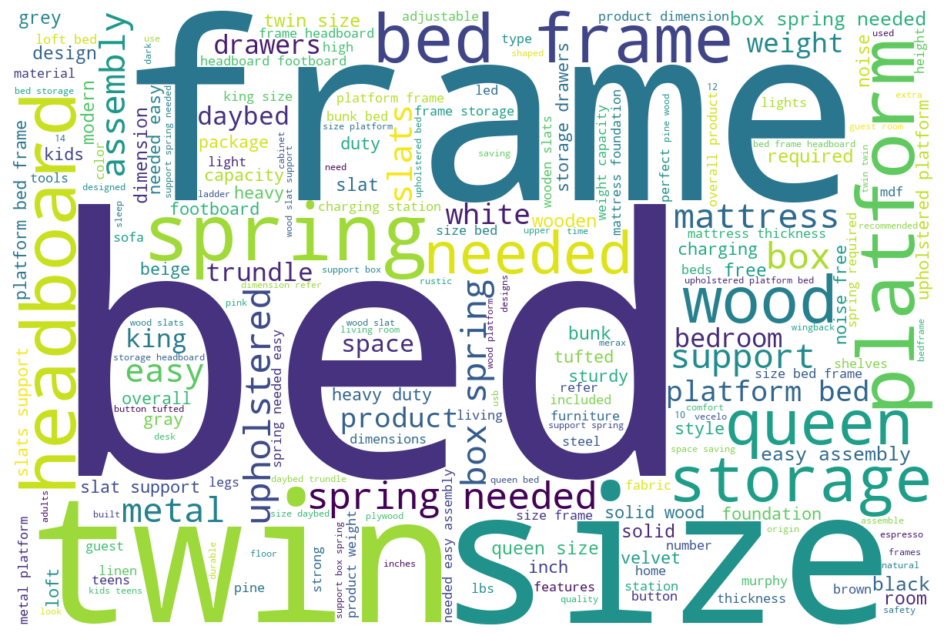

Top 50 keywords/ngrams:
              keyword   count
0                 bed  278178
1               frame  179576
2                size  131460
3                twin  116547
4              spring  109890
5            platform  105856
6           headboard   97764
7           bed frame   91460
8                wood   85879
9             storage   82292
10              queen   81203
11             needed   77839
12      spring needed   75151
13                box   69973
14        upholstered   68647
15           mattress   61728
16              metal   60686
17         box spring   59721
18            support   58894
19           assembly   58449
20              slats   52533
21               easy   51736
22       platform bed   51444
23              white   50618
24            product   48284
25             weight   45727
26            drawers   44278
27            bedroom   44261
28               king   42889
29             daybed   42464
30            trundle   41762
31              

In [57]:
def collect_texts(df):
    """title, keywords_list, description만 합쳐서 하나의 문자열로 반환"""
    def _norm_list(x):
        if isinstance(x, list):
            return x
        if isinstance(x, str):
            return [t.strip() for t in x.split(",") if t.strip()]
        return []
    
    texts = []
    for _, row in df.iterrows():
        title = str(row.get("title") or "")
        desc = str(row.get("description") or "")
        kw_list = _norm_list(row.get("keywords_list"))
        kw = " ".join(map(str, kw_list))
        txt = " ".join([title, kw, desc]).lower()
        txt = re.sub(r"[^a-z0-9 ]+", " ", txt)
        txt = re.sub(r"\s+", " ", txt).strip()
        texts.append(txt)
    return texts


def make_wordcloud(df, ngram_range=(1,3), max_words=200, top_n=30):
    texts = collect_texts(df)
    
    # 단어/구 빈도 계산
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(texts)
    freqs = dict(zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1))
    
    # ===== 워드 클라우드 =====
    wc = WordCloud(width=1200, height=800,
                   background_color="white",
                   colormap="viridis",
                   max_words=max_words).generate_from_frequencies(freqs)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()
    
    # ===== 키워드 + 빈도수 출력 =====
    freq_df = pd.DataFrame(freqs.items(), columns=["keyword", "count"])
    freq_df = freq_df.sort_values("count", ascending=False).reset_index(drop=True)
    
    print(f"Top {top_n} keywords/ngrams:")
    print(freq_df.head(top_n))
    
    return freq_df


# 사용 예시
# df = pd.read_csv("your_data.csv")
freq_table = make_wordcloud(df, ngram_range=(1,3), max_words=200, top_n=50)

In [59]:
def collect_texts(df):
    """title, keywords_list, description만 합쳐서 하나의 문자열로 반환"""
    def _norm_list(x):
        if isinstance(x, list):
            return x
        if isinstance(x, str):
            return [t.strip() for t in x.split(",") if t.strip()]
        return []
    
    texts = []
    for _, row in df.iterrows():
        title = str(row.get("title") or "")
        desc = str(row.get("description") or "")
        kw_list = _norm_list(row.get("keywords_list"))
        kw = " ".join(map(str, kw_list))
        txt = " ".join([title, kw, desc]).lower()
        txt = re.sub(r"[^a-z0-9 ]+", " ", txt)
        txt = re.sub(r"\s+", " ", txt).strip()
        texts.append(txt)
    return texts


def keyword_frequencies(df, ngram_range=(1,3)):
    texts = collect_texts(df)
    
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(texts)
    freqs = dict(zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1))
    
    # 모든 키워드와 빈도수 DataFrame 생성
    freq_df = pd.DataFrame(freqs.items(), columns=["keyword", "count"])
    freq_df = freq_df.sort_values("count", ascending=False).reset_index(drop=True)
    return freq_df


# 사용 예시
# df = pd.read_csv("your_data.csv")
freq_table = keyword_frequencies(df, ngram_range=(1,3))
print(freq_table)

                          keyword   count
0                             bed  278178
1                           frame  179576
2                            size  131460
3                            twin  116547
4                          spring  109890
...                           ...     ...
1156917  provides minimal partner       1
1156918          provides minimal       1
1156919      provides memory foam       1
1156920           provides memory       1
1156921        zzz stylish daybed       1

[1156922 rows x 2 columns]


In [61]:
freq_table.to_csv('non_mattress_keywords.csv')